In [ ]:
print("Python runtime is working correctly.")

Python runtime is working correctly.


# Predicting 30-Day Hospital Readmission Among Patients With Diabetes

## Project Objective
This project develops and compares interpretable machine-learning models to predict whether a patient with diabetes is readmitted to a hospital within 30 days of discharge.

The analysis will focus on careful data preparation, model validation, probability calibration, and clear interpretation of the factors associated with readmission risk.

## 1. Setup and Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Basic libraries imported successfully.")

Basic libraries imported successfully.


## 2. Load the Clinical Dataset

In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load the Diabetes 130-US Hospitals dataset from the UCI Repository
diabetes_data = fetch_ucirepo(id=296)

# Separate predictors and outcome variable
X = diabetes_data.data.features
y = diabetes_data.data.targets

print("Dataset loaded successfully.")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset loaded successfully.
Feature matrix shape: (101766, 47)
Target shape: (101766, 1)


In [ ]:
print("First five rows of the predictor dataset:")
display(X.head())

print("\nOutcome categories and frequencies:")
print(y.iloc[:, 0].value_counts(dropna=False))

First five rows of the predictor dataset:


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes



Outcome categories and frequencies:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [ ]:
# Create a working copy of the predictor dataset
df = X.copy()

# Add the original readmission outcome
df["readmitted_original"] = y.iloc[:, 0]

# Create a binary outcome:
# 1 = readmitted within 30 days
# 0 = no readmission within 30 days
df["readmitted_30_days"] = (
    df["readmitted_original"] == "<30"
).astype(int)

print("Working dataset created successfully.")
print("Dataset shape:", df.shape)

print("\nBinary outcome frequencies:")
print(df["readmitted_30_days"].value_counts())

print("\nBinary outcome percentages:")
print(
    df["readmitted_30_days"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Working dataset created successfully.
Dataset shape: (101766, 49)

Binary outcome frequencies:
readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64

Binary outcome percentages:
readmitted_30_days
0    88.84
1    11.16
Name: proportion, dtype: float64


## 3. Initial Data Audit

In [ ]:
# Calculate missing-value counts and percentages
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

# Keep only variables with missing values
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values(by="missing_percentage", ascending=False)
)

print("Variables with missing values:")
display(missing_summary)

print("\nNumber of variables with missing values:", missing_summary.shape[0])

Variables with missing values:


,missing_count,missing_percentage
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02



Number of variables with missing values: 9


In [ ]:
# Summarize variable types and number of unique values
variable_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

# Display all variables
display(variable_summary)

print("Number of variables:", variable_summary.shape[0])

,data_type,unique_values,missing_percentage
race,object,6,2.23
gender,object,3,0.00
age,object,10,0.00
weight,object,10,96.86
admission_type_id,int64,8,0.00
discharge_disposition_id,int64,26,0.00
admission_source_id,int64,17,0.00
time_in_hospital,int64,14,0.00
payer_code,object,18,39.56
medical_specialty,object,73,49.08


Number of variables: 49


In [ ]:
# Keep only candidate predictor variables for this audit
predictor_df = df.drop(
    columns=["readmitted_original", "readmitted_30_days"]
)

# Create a summary of variables with little or no variation
variation_summary = []

for column in predictor_df.columns:
    value_proportions = predictor_df[column].value_counts(
        dropna=False,
        normalize=True
    )

    variation_summary.append({
        "variable": column,
        "unique_values": predictor_df[column].nunique(dropna=False),
        "most_common_value": value_proportions.index[0],
        "most_common_percentage": round(value_proportions.iloc[0] * 100, 2)
    })

variation_summary = pd.DataFrame(variation_summary)

# Show constant variables
constant_variables = variation_summary[
    variation_summary["unique_values"] == 1
]

print("Constant variables:")
display(constant_variables)

# Show variables where one value accounts for at least 95% of observations
print("\nVariables with a dominant value in at least 95% of observations:")
display(
    variation_summary[
        variation_summary["most_common_percentage"] >= 95
    ].sort_values(
        by="most_common_percentage",
        ascending=False
    )
)

Constant variables:


,variable,unique_values,most_common_value,most_common_percentage
37,examide,1,No,100.0
38,citoglipton,1,No,100.0



Variables with a dominant value in at least 95% of observations:


,variable,unique_values,most_common_value,most_common_percentage
27,acetohexamide,2,No,100.00
42,glimepiride-pioglitazone,2,No,100.00
35,troglitazone,2,No,100.00
38,citoglipton,1,No,100.00
44,metformin-pioglitazone,2,No,100.00
37,examide,1,No,100.00
43,metformin-rosiglitazone,2,No,100.00
41,glipizide-metformin,2,No,99.99
30,tolbutamide,2,No,99.98
36,tolazamide,3,No,99.96


In [ ]:
# Inspect identifier columns stored separately by the UCI package
print("Identifier columns:")
display(diabetes_data.data.ids.head())

print("\nIdentifier dataset shape:")
print(diabetes_data.data.ids.shape)

print("\nIdentifier column names:")
print(diabetes_data.data.ids.columns.tolist())

Identifier columns:


,encounter_id,patient_nbr
0,2278392,8222157
1,149190,55629189
2,64410,86047875
3,500364,82442376
4,16680,42519267



Identifier dataset shape:
(101766, 2)

Identifier column names:
['encounter_id', 'patient_nbr']


In [ ]:
# Create a copy of the identifier dataset
ids = diabetes_data.data.ids.copy()

# Count encounters per patient
encounters_per_patient = ids["patient_nbr"].value_counts()

print("Total hospital encounters:", ids.shape[0])
print("Unique patients:", ids["patient_nbr"].nunique())

print("\nPatients with more than one encounter:")
print((encounters_per_patient > 1).sum())

print("\nPercentage of patients with repeated encounters:")
print(
    round(
        (encounters_per_patient > 1).mean() * 100,
        2
    ),
    "%"
)

print("\nMaximum number of encounters for one patient:")
print(encounters_per_patient.max())

print("\nEncounter-count distribution:")
display(
    encounters_per_patient
    .value_counts()
    .sort_index()
    .head(15)
    .rename_axis("encounters_per_patient")
    .reset_index(name="number_of_patients")
)

Total hospital encounters: 101766
Unique patients: 71518

Patients with more than one encounter:
16773

Percentage of patients with repeated encounters:
23.45 %

Maximum number of encounters for one patient:
40

Encounter-count distribution:


,encounters_per_patient,number_of_patients
0,1,54745
1,2,10434
2,3,3328
3,4,1421
4,5,717
5,6,346
6,7,207
7,8,111
8,9,70
9,10,42


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Use patient identifiers as grouping variables
patient_groups = ids["patient_nbr"]

# Create an 80% development set and a 20% test set
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

development_index, test_index = next(
    group_split.split(
        df,
        y=df["readmitted_30_days"],
        groups=patient_groups
    )
)

# Create separate datasets
development_df = df.iloc[development_index].copy()
test_df = df.iloc[test_index].copy()

development_ids = ids.iloc[development_index].copy()
test_ids = ids.iloc[test_index].copy()

# Verify that no patient appears in both datasets
overlapping_patients = set(
    development_ids["patient_nbr"]
).intersection(
    set(test_ids["patient_nbr"])
)

print("Development-set encounters:", development_df.shape[0])
print("Test-set encounters:", test_df.shape[0])

print("\nDevelopment-set patients:", development_ids["patient_nbr"].nunique())
print("Test-set patients:", test_ids["patient_nbr"].nunique())

print("\nPatients appearing in both datasets:", len(overlapping_patients))

print("\n30-day readmission rate in development set:")
print(round(development_df["readmitted_30_days"].mean() * 100, 2), "%")

print("\n30-day readmission rate in test set:")
print(round(test_df["readmitted_30_days"].mean() * 100, 2), "%")

Development-set encounters: 81613
Test-set encounters: 20153

Development-set patients: 57214
Test-set patients: 14304

Patients appearing in both datasets: 0

30-day readmission rate in development set:
11.28 %

30-day readmission rate in test set:
10.67 %


In [ ]:
# Separate predictors and binary outcomes for modeling

X_development_raw = development_df.drop(
    columns=["readmitted_original", "readmitted_30_days"]
)

y_development = development_df["readmitted_30_days"].copy()

X_test_raw = test_df.drop(
    columns=["readmitted_original", "readmitted_30_days"]
)

y_test = test_df["readmitted_30_days"].copy()

# Keep patient groups for leakage-safe cross-validation later
groups_development = development_ids["patient_nbr"].copy()
groups_test = test_ids["patient_nbr"].copy()

print("Raw modeling datasets prepared successfully.")

print("\nDevelopment predictors shape:", X_development_raw.shape)
print("Development outcome shape:", y_development.shape)

print("\nTest predictors shape:", X_test_raw.shape)
print("Test outcome shape:", y_test.shape)

print("\nDevelopment patient groups:", groups_development.nunique())
print("Test patient groups:", groups_test.nunique())

Raw modeling datasets prepared successfully.

Development predictors shape: (81613, 47)
Development outcome shape: (81613,)

Test predictors shape: (20153, 47)
Test outcome shape: (20153,)

Development patient groups: 57214
Test patient groups: 14304


## 4. Predictor Cleaning and Preparation

In [ ]:
# Create cleaned copies of the raw predictor datasets
X_development_clean = X_development_raw.copy()
X_test_clean = X_test_raw.copy()

# Remove predictors that are clearly unusable
initial_drop_columns = [
    "weight",
    "examide",
    "citoglipton"
]

X_development_clean = X_development_clean.drop(
    columns=initial_drop_columns
)

X_test_clean = X_test_clean.drop(
    columns=initial_drop_columns
)

print("Initial predictor cleaning completed successfully.")

print("\nRemoved columns:")
print(initial_drop_columns)

print("\nDevelopment predictor shape:", X_development_clean.shape)
print("Test predictor shape:", X_test_clean.shape)

print(
    "\nPredictor columns aligned across both datasets:",
    X_development_clean.columns.equals(X_test_clean.columns)
)

Initial predictor cleaning completed successfully.

Removed columns:
['weight', 'examide', 'citoglipton']

Development predictor shape: (81613, 44)
Test predictor shape: (20153, 44)

Predictor columns aligned across both datasets: True


In [ ]:
# Audit missing values in the development predictors only
development_missing_summary = pd.DataFrame({
    "missing_count": X_development_clean.isna().sum(),
    "missing_percentage": (
        X_development_clean.isna().mean() * 100
    ).round(2)
})

development_missing_summary = (
    development_missing_summary[
        development_missing_summary["missing_count"] > 0
    ]
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
)

print("Missing values in the development predictors:")
display(development_missing_summary)

print(
    "\nNumber of development predictors with missing values:",
    development_missing_summary.shape[0]
)

Missing values in the development predictors:


,missing_count,missing_percentage
max_glu_serum,77260,94.67
A1Cresult,67938,83.24
medical_specialty,39835,48.81
payer_code,32315,39.60
race,1863,2.28
diag_3,1138,1.39
diag_2,294,0.36
diag_1,14,0.02



Number of development predictors with missing values: 8


In [ ]:
# Inspect the most common values in variables with missing data
missing_columns = development_missing_summary.index.tolist()

for column in missing_columns:
    print("=" * 70)
    print("Variable:", column)
    print("Data type:", X_development_clean[column].dtype)
    print("Unique values including missing:", X_development_clean[column].nunique(dropna=False))

    print("\nMost common values:")
    display(
        X_development_clean[column]
        .value_counts(dropna=False)
        .head(10)
        .rename_axis("value")
        .reset_index(name="count")
    )

Variable: max_glu_serum
Data type: object
Unique values including missing: 4

Most common values:


,value,count
0,NaN,77260
1,Norm,2124
2,>200,1227
3,>300,1002


Variable: A1Cresult
Data type: object
Unique values including missing: 4

Most common values:


,value,count
0,NaN,67938
1,>8,6605
2,Norm,3982
3,>7,3088


Variable: medical_specialty
Data type: object
Unique values including missing: 72

Most common values:


...

,value,count
0,250,9292
1,401,6654
2,276,4202
3,428,3672
4,427,3136
5,414,2949
6,496,2095
7,403,1875
8,585,1590
9,599,1568


Variable: diag_2
Data type: object
Unique values including missing: 720

Most common values:


,value,count
0,276,5418
1,428,5359
2,250,4830
3,427,4018
4,401,2989
5,496,2677
6,599,2669
7,403,2227
8,414,2157
9,411,2074


Variable: diag_1
Data type: object
Unique values including missing: 701

Most common values:


,value,count
0,428,5503
1,414,5278
2,786,3224
3,410,2902
4,486,2840
5,427,2224
6,491,1835
7,715,1733
8,682,1677
9,780,1616


In [ ]:
# Create a reusable function for categorical missing-value handling
def fill_categorical_missing_values(data):
    data = data.copy()

    # Missing laboratory results may indicate that the test was not measured
    laboratory_columns = [
        "max_glu_serum",
        "A1Cresult"
    ]

    data[laboratory_columns] = data[laboratory_columns].fillna(
        "Not_measured"
    )

    # Use a general missing category for the remaining categorical variables
    general_missing_columns = [
        "medical_specialty",
        "payer_code",
        "race",
        "diag_1",
        "diag_2",
        "diag_3"
    ]

    data[general_missing_columns] = data[
        general_missing_columns
    ].fillna("Missing")

    return data


# Apply the same rule to the development and protected test datasets
X_development_prepared = fill_categorical_missing_values(
    X_development_clean
)

X_test_prepared = fill_categorical_missing_values(
    X_test_clean
)

print("Missing-value categories encoded successfully.")

print(
    "\nRemaining missing values in development predictors:",
    X_development_prepared.isna().sum().sum()
)

print(
    "Remaining missing values in test predictors:",
    X_test_prepared.isna().sum().sum()
)

print("\nA1C result categories in the development set:")
print(
    X_development_prepared["A1Cresult"]
    .value_counts()
)

print("\nRace categories in the development set:")
print(
    X_development_prepared["race"]
    .value_counts()
)

Missing-value categories encoded successfully.

Remaining missing values in development predictors: 0
Remaining missing values in test predictors: 0

A1C result categories in the development set:
A1Cresult
Not_measured    67938
>8               6605
Norm             3982
>7               3088
Name: count, dtype: int64

Race categories in the development set:
race
Caucasian          61010
AfricanAmerican    15363
Missing             1863
Hispanic            1644
Other               1217
Asian                516
Name: count, dtype: int64


In [ ]:
# Create a reusable function to group diagnosis codes
def group_diagnosis_code(code):
    """
    Convert detailed diagnosis codes into broader clinical categories.
    """

    # Preserve the explicit missing-value category
    if code == "Missing":
        return "Missing"

    # Convert the code to text for safe processing
    code = str(code).strip()

    # Handle supplementary codes such as V-codes and E-codes
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    # Convert numeric diagnosis codes safely
    try:
        numeric_code = float(code)
    except ValueError:
        return "Other"

    # Group diagnosis codes into broader categories
    if 390 <= numeric_code <= 459 or numeric_code == 785:
        return "Circulatory"

    elif 460 <= numeric_code <= 519 or numeric_code == 786:
        return "Respiratory"

    elif 520 <= numeric_code <= 579 or numeric_code == 787:
        return "Digestive"

    elif 250 <= numeric_code < 251:
        return "Diabetes"

    elif 800 <= numeric_code <= 999:
        return "Injury"

    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal"

    elif 580 <= numeric_code <= 629 or numeric_code == 788:
        return "Genitourinary"

    elif 140 <= numeric_code <= 239:
        return "Neoplasms"

    else:
        return "Other"


# Test the function with example diagnosis codes
example_codes = [
    "250",
    "428",
    "486",
    "715",
    "585",
    "V57",
    "E878",
    "Missing"
]

for code in example_codes:
    print(code, "->", group_diagnosis_code(code))

250 -> Diabetes
428 -> Circulatory
486 -> Respiratory
715 -> Musculoskeletal
585 -> Genitourinary
V57 -> Other
E878 -> Other
Missing -> Missing


In [ ]:
# Create grouped diagnosis variables in both datasets
diagnosis_columns = [
    "diag_1",
    "diag_2",
    "diag_3"
]

for column in diagnosis_columns:
    grouped_column = column + "_group"

    X_development_prepared[grouped_column] = (
        X_development_prepared[column]
        .apply(group_diagnosis_code)
    )

    X_test_prepared[grouped_column] = (
        X_test_prepared[column]
        .apply(group_diagnosis_code)
    )

print("Grouped diagnosis variables created successfully.")

print("\nNew grouped diagnosis columns:")
print([
    "diag_1_group",
    "diag_2_group",
    "diag_3_group"
])

print("\nPrimary diagnosis-group distribution in the development set:")
display(
    X_development_prepared["diag_1_group"]
    .value_counts()
    .rename_axis("diagnosis_group")
    .reset_index(name="count")
)

print(
    "\nDevelopment predictor shape:",
    X_development_prepared.shape
)

print(
    "Test predictor shape:",
    X_test_prepared.shape
)

Grouped diagnosis variables created successfully.

New grouped diagnosis columns:
['diag_1_group', 'diag_2_group', 'diag_3_group']

Primary diagnosis-group distribution in the development set:


,diagnosis_group,count
0,Circulatory,24409
1,Other,14637
2,Respiratory,11586
3,Digestive,7583
4,Diabetes,7027
5,Injury,5566
6,Genitourinary,4089
7,Musculoskeletal,3957
8,Neoplasms,2745
9,Missing,14



Development predictor shape: (81613, 47)
Test predictor shape: (20153, 47)


In [ ]:
# Remove the original detailed diagnosis-code variables
raw_diagnosis_columns = [
    "diag_1",
    "diag_2",
    "diag_3"
]

X_development_prepared = X_development_prepared.drop(
    columns=raw_diagnosis_columns
)

X_test_prepared = X_test_prepared.drop(
    columns=raw_diagnosis_columns
)

print("Raw diagnosis-code variables removed successfully.")

print("\nRemoved columns:")
print(raw_diagnosis_columns)

print(
    "\nDevelopment predictor shape:",
    X_development_prepared.shape
)

print(
    "Test predictor shape:",
    X_test_prepared.shape
)

print(
    "\nPredictor columns aligned across both datasets:",
    X_development_prepared.columns.equals(
        X_test_prepared.columns
    )
)

Raw diagnosis-code variables removed successfully.

Removed columns:
['diag_1', 'diag_2', 'diag_3']

Development predictor shape: (81613, 44)
Test predictor shape: (20153, 44)

Predictor columns aligned across both datasets: True


In [ ]:
# Audit discharge-disposition categories using the development set only
disposition_audit = pd.DataFrame({
    "discharge_disposition_id": (
        X_development_prepared["discharge_disposition_id"]
        .reset_index(drop=True)
    ),
    "readmitted_30_days": (
        y_development
        .reset_index(drop=True)
    )
})

disposition_summary = (
    disposition_audit
    .groupby("discharge_disposition_id")
    .agg(
        encounters=("readmitted_30_days", "size"),
        readmitted_within_30_days=("readmitted_30_days", "sum"),
        readmission_rate_percentage=(
            "readmitted_30_days",
            lambda values: round(values.mean() * 100, 2)
        )
    )
    .sort_values(
        by="encounters",
        ascending=False
    )
    .reset_index()
)

print("Discharge-disposition audit:")
display(disposition_summary)

print(
    "\nNumber of discharge-disposition categories:",
    disposition_summary.shape[0]
)

Discharge-disposition audit:


,discharge_disposition_id,encounters,readmitted_within_30_days,readmission_rate_percentage
0,1,48274,4541,9.41
1,3,11232,1673,14.89
2,6,10312,1318,12.78
3,18,2957,374,12.65
4,2,1716,275,16.03
5,22,1605,441,27.48
6,11,1325,0,0.00
7,5,955,199,20.84
8,25,789,78,9.89
9,4,664,85,12.80



Number of discharge-disposition categories: 26


In [ ]:
import io
import zipfile
import requests

# Official UCI ZIP file containing the dataset and ID mappings
uci_zip_url = (
    "https://archive.ics.uci.edu/static/public/296/"
    "diabetes%2B130-us%2Bhospitals%2Bfor%2Byears%2B1999-2008.zip"
)

# Download the official ZIP file
response = requests.get(
    uci_zip_url,
    timeout=30
)

response.raise_for_status()

# Read the mapping file stored inside the ZIP archive
with zipfile.ZipFile(
    io.BytesIO(response.content)
) as archive:

    print("Files inside the official UCI ZIP archive:")
    print(archive.namelist())

    with archive.open("IDS_mapping.csv") as mapping_file:
        mapping_text = mapping_file.read().decode(
            "utf-8",
            errors="replace"
        )

print("\nFirst 45 lines of the official mapping file:\n")

for line_number, line in enumerate(
    mapping_text.splitlines()[:45]
):
    print(f"{line_number:02d}: {line}")

Files inside the official UCI ZIP archive:
['diabetic_data.csv', 'IDS_mapping.csv']

First 45 lines of the official mapping file:

00: admission_type_id,description
01: 1,Emergency
02: 2,Urgent
03: 3,Elective
04: 4,Newborn
05: 5,Not Available
06: 6,NULL
07: 7,Trauma Center
08: 8,Not Mapped
09: ,
10: discharge_disposition_id,description
11: 1,Discharged to home
12: 2,Discharged/transferred to another short term hospital
13: 3,Discharged/transferred to SNF
14: 4,Discharged/transferred to ICF
15: 5,Discharged/transferred to another type of inpatient care institution
16: 6,Discharged/transferred to home with home health service
17: 7,Left AMA
18: 8,Discharged/transferred to home under care of Home IV provider
19: 9,Admitted as an inpatient to this hospital
20: 10,Neonate discharged to another hospital for neonatal aftercare
21: 11,Expired
22: 12,Still patient or expected to return for outpatient services
23: 13,Hospice / home
24: 14,Hospice / medical facility
25: 15,Discharged/transferred 

In [ ]:
# Exclude encounters where 30-day readmission is not a comparable outcome
# because the patient expired or entered hospice care.

ineligible_disposition_ids = [
    11,  # Expired
    13,  # Hospice / home
    14,  # Hospice / medical facility
    19,  # Expired at home, Medicaid only, hospice
    20,  # Expired in a medical facility, Medicaid only, hospice
    21   # Expired, place unknown, Medicaid only
]

# Create eligibility masks
development_eligible_mask = ~X_development_prepared[
    "discharge_disposition_id"
].isin(ineligible_disposition_ids)

test_eligible_mask = ~X_test_prepared[
    "discharge_disposition_id"
].isin(ineligible_disposition_ids)

# Count excluded encounters before filtering
development_excluded_count = (~development_eligible_mask).sum()
test_excluded_count = (~test_eligible_mask).sum()

# Apply the same filter consistently to predictors, outcomes, and groups
X_development_eligible = X_development_prepared.loc[
    development_eligible_mask
].copy()

y_development_eligible = y_development.loc[
    development_eligible_mask
].copy()

groups_development_eligible = groups_development.loc[
    development_eligible_mask
].copy()

X_test_eligible = X_test_prepared.loc[
    test_eligible_mask
].copy()

y_test_eligible = y_test.loc[
    test_eligible_mask
].copy()

groups_test_eligible = groups_test.loc[
    test_eligible_mask
].copy()

# Verify that patient-level separation remains intact
overlapping_patients_after_filtering = set(
    groups_development_eligible
).intersection(
    set(groups_test_eligible)
)

print("Clinical eligibility filtering completed successfully.")

print("\nExcluded development-set encounters:", development_excluded_count)
print("Excluded test-set encounters:", test_excluded_count)

print("\nEligible development-set encounters:", X_development_eligible.shape[0])
print("Eligible test-set encounters:", X_test_eligible.shape[0])

print("\nDevelopment-set readmission rate:")
print(round(y_development_eligible.mean() * 100, 2), "%")

print("\nTest-set readmission rate:")
print(round(y_test_eligible.mean() * 100, 2), "%")

print(
    "\nPatients appearing in both datasets after filtering:",
    len(overlapping_patients_after_filtering)
)

Clinical eligibility filtering completed successfully.

Excluded development-set encounters: 1958
Excluded test-set encounters: 465

Eligible development-set encounters: 79655
Eligible test-set encounters: 19688

Development-set readmission rate:
11.52 %

Test-set readmission rate:
10.86 %

Patients appearing in both datasets after filtering: 0


In [ ]:
# Reset indices so that predictors, outcomes, and patient groups
# remain cleanly aligned for the modeling workflow.

X_development_final = (
    X_development_eligible
    .reset_index(drop=True)
    .copy()
)

y_development_final = (
    y_development_eligible
    .reset_index(drop=True)
    .copy()
)

groups_development_final = (
    groups_development_eligible
    .reset_index(drop=True)
    .copy()
)

X_test_final = (
    X_test_eligible
    .reset_index(drop=True)
    .copy()
)

y_test_final = (
    y_test_eligible
    .reset_index(drop=True)
    .copy()
)

groups_test_final = (
    groups_test_eligible
    .reset_index(drop=True)
    .copy()
)

# Verify alignment
print("Eligible datasets locked successfully.")

print("\nDevelopment predictor shape:", X_development_final.shape)
print("Development outcome shape:", y_development_final.shape)
print("Development group shape:", groups_development_final.shape)

print("\nTest predictor shape:", X_test_final.shape)
print("Test outcome shape:", y_test_final.shape)
print("Test group shape:", groups_test_final.shape)

print(
    "\nRemaining missing values in development predictors:",
    X_development_final.isna().sum().sum()
)

print(
    "Remaining missing values in test predictors:",
    X_test_final.isna().sum().sum()
)

Eligible datasets locked successfully.

Development predictor shape: (79655, 44)
Development outcome shape: (79655,)
Development group shape: (79655,)

Test predictor shape: (19688, 44)
Test outcome shape: (19688,)
Test group shape: (19688,)

Remaining missing values in development predictors: 0
Remaining missing values in test predictors: 0


In [ ]:
# Create a reusable function to convert age bands into midpoints
def convert_age_band_to_midpoint(age_band):
    age_midpoint_mapping = {
        "[0-10)": 5,
        "[10-20)": 15,
        "[20-30)": 25,
        "[30-40)": 35,
        "[40-50)": 45,
        "[50-60)": 55,
        "[60-70)": 65,
        "[70-80)": 75,
        "[80-90)": 85,
        "[90-100)": 95
    }

    return age_midpoint_mapping.get(age_band)


# Create the numerical age variable in both datasets
X_development_final["age_midpoint"] = (
    X_development_final["age"]
    .apply(convert_age_band_to_midpoint)
)

X_test_final["age_midpoint"] = (
    X_test_final["age"]
    .apply(convert_age_band_to_midpoint)
)

# Remove the original age-band variable
X_development_final = X_development_final.drop(
    columns=["age"]
)

X_test_final = X_test_final.drop(
    columns=["age"]
)

print("Age bands converted successfully.")

print("\nAge-midpoint distribution in the development set:")
display(
    X_development_final["age_midpoint"]
    .value_counts()
    .sort_index()
    .rename_axis("age_midpoint")
    .reset_index(name="count")
)

print(
    "\nDevelopment predictor shape:",
    X_development_final.shape
)

print(
    "Test predictor shape:",
    X_test_final.shape
)

print(
    "\nRemaining missing age values in development set:",
    X_development_final["age_midpoint"].isna().sum()
)

print(
    "Remaining missing age values in test set:",
    X_test_final["age_midpoint"].isna().sum()
)

Age bands converted successfully.

Age-midpoint distribution in the development set:


,age_midpoint,count
0,5,122
1,15,553
2,25,1365
3,35,2961
4,45,7727
5,55,13589
6,65,17628
7,75,20344
8,85,13264
9,95,2102



Development predictor shape: (79655, 44)
Test predictor shape: (19688, 44)

Remaining missing age values in development set: 0
Remaining missing age values in test set: 0


## 5. Feature Encoding and Baseline Model Preparation

In [ ]:
# Identify categorical ID variables that are stored as integers
categorical_id_columns = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# Identify text-based categorical variables automatically
object_columns = (
    X_development_final
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

# Combine both types of categorical predictors
categorical_features = sorted(
    list(
        set(
            categorical_id_columns + object_columns
        )
    )
)

# All remaining predictors are numerical
numeric_features = [
    column
    for column in X_development_final.columns
    if column not in categorical_features
]

print("Predictor roles identified successfully.")

print("\nNumber of categorical predictors:", len(categorical_features))
print("Number of numerical predictors:", len(numeric_features))

print("\nCategorical predictors:")
print(categorical_features)

print("\nNumerical predictors:")
print(numeric_features)

print(
    "\nTotal predictors accounted for:",
    len(categorical_features) + len(numeric_features)
)

print(
    "Total predictors in the dataset:",
    X_development_final.shape[1]
)

Predictor roles identified successfully.

Number of categorical predictors: 35
Number of numerical predictors: 9

Categorical predictors:
['A1Cresult', 'acarbose', 'acetohexamide', 'admission_source_id', 'admission_type_id', 'change', 'chlorpropamide', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'discharge_disposition_id', 'gender', 'glimepiride', 'glimepiride-pioglitazone', 'glipizide', 'glipizide-metformin', 'glyburide', 'glyburide-metformin', 'insulin', 'max_glu_serum', 'medical_specialty', 'metformin', 'metformin-pioglitazone', 'metformin-rosiglitazone', 'miglitol', 'nateglinide', 'payer_code', 'pioglitazone', 'race', 'repaglinide', 'rosiglitazone', 'tolazamide', 'tolbutamide', 'troglitazone']

Numerical predictors:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint']

Total predictors accounted for: 44
Total predictors in the dataset: 44


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocess categorical variables:
# - create one-hot encoded indicators;
# - safely ignore categories that may appear later but were not seen during fitting;
# - group extremely rare categories together.
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    min_frequency=20
)

# Standardize numerical variables for the baseline regression model
numeric_transformer = StandardScaler()

# Combine categorical and numerical preprocessing rules
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numeric",
            numeric_transformer,
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

print("\nCategorical predictors assigned:", len(categorical_features))
print("Numerical predictors assigned:", len(numeric_features))
print(
    "Total predictors assigned:",
    len(categorical_features) + len(numeric_features)
)

Preprocessing pipeline created successfully.

Categorical predictors assigned: 35
Numerical predictors assigned: 9
Total predictors assigned: 44


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create an interpretable baseline model
baseline_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

# Combine preprocessing and modeling into one reproducible pipeline
baseline_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            baseline_logistic_model
        )
    ]
)

print("Baseline logistic-regression pipeline created successfully.")

print("\nModel type:")
print(type(baseline_logistic_pipeline.named_steps["model"]).__name__)

print("\nClass-weight setting:")
print(
    baseline_logistic_pipeline
    .named_steps["model"]
    .class_weight
)

print("\nPipeline steps:")
print(
    list(
        baseline_logistic_pipeline.named_steps.keys()
    )
)

Baseline logistic-regression pipeline created successfully.

Model type:
LogisticRegression

Class-weight setting:
balanced

Pipeline steps:
['preprocessing', 'model']


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Create five leakage-safe cross-validation folds
group_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Inspect each fold before fitting any model
fold_summary = []

for fold_number, (train_index, validation_index) in enumerate(
    group_cv.split(
        X_development_final,
        y_development_final,
        groups=groups_development_final
    ),
    start=1
):
    train_patients = set(
        groups_development_final.iloc[train_index]
    )

    validation_patients = set(
        groups_development_final.iloc[validation_index]
    )

    overlapping_patients = train_patients.intersection(
        validation_patients
    )

    fold_summary.append({
        "fold": fold_number,
        "training_encounters": len(train_index),
        "validation_encounters": len(validation_index),
        "training_readmission_rate_percentage": round(
            y_development_final.iloc[train_index].mean() * 100,
            2
        ),
        "validation_readmission_rate_percentage": round(
            y_development_final.iloc[validation_index].mean() * 100,
            2
        ),
        "overlapping_patients": len(overlapping_patients)
    })

fold_summary = pd.DataFrame(fold_summary)

print("Leakage-safe cross-validation plan created successfully.\n")

display(fold_summary)

Leakage-safe cross-validation plan created successfully.



,fold,training_encounters,validation_encounters,training_readmission_rate_percentage,validation_readmission_rate_percentage,overlapping_patients
0,1,63568,16087,11.51,11.56,0
1,2,63963,15692,11.61,11.15,0
2,3,63730,15925,11.48,11.68,0
3,4,63727,15928,11.48,11.66,0
4,5,63632,16023,11.51,11.54,0


In [ ]:
from sklearn.model_selection import cross_validate

# Define evaluation metrics for the imbalanced binary outcome
scoring_metrics = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy"
}

# Evaluate the baseline model using leakage-safe cross-validation
baseline_cv_results = cross_validate(
    estimator=baseline_logistic_pipeline,
    X=X_development_final,
    y=y_development_final,
    groups=groups_development_final,
    cv=group_cv,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False
)

# Summarize fold-level model performance
baseline_cv_summary = pd.DataFrame({
    "fold": range(1, 6),
    "roc_auc": baseline_cv_results["test_roc_auc"],
    "pr_auc": baseline_cv_results["test_pr_auc"],
    "recall": baseline_cv_results["test_recall"],
    "precision": baseline_cv_results["test_precision"],
    "balanced_accuracy": baseline_cv_results["test_balanced_accuracy"]
})

print("Baseline logistic-regression cross-validation completed successfully.\n")

display(
    baseline_cv_summary.round(3)
)

print("\nMean cross-validation performance:")

display(
    baseline_cv_summary
    .drop(columns=["fold"])
    .agg(["mean", "std"])
    .round(3)
)

Baseline logistic-regression cross-validation completed successfully.



,fold,roc_auc,pr_auc,recall,precision,balanced_accuracy
0,1,0.670,0.222,0.558,0.184,0.617
1,2,0.655,0.206,0.528,0.173,0.606
2,3,0.669,0.223,0.554,0.190,0.621
3,4,0.652,0.208,0.535,0.178,0.605
4,5,0.667,0.225,0.544,0.187,0.617



Mean cross-validation performance:


,roc_auc,pr_auc,recall,precision,balanced_accuracy
mean,0.663,0.217,0.544,0.183,0.613
std,0.008,0.009,0.012,0.007,0.007


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    make_scorer,
    precision_score
)

# Create a numerical placeholder predictor because DummyClassifier
# intentionally ignores predictor information.
dummy_X = np.zeros(
    shape=(len(y_development_final), 1)
)

# Create a no-skill benchmark model
dummy_model = DummyClassifier(
    strategy="prior"
)

# Avoid unnecessary warnings when the dummy model predicts no positives
dummy_scoring_metrics = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "recall": "recall",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "balanced_accuracy": "balanced_accuracy"
}

# Evaluate the no-skill model using the same leakage-safe folds
dummy_cv_results = cross_validate(
    estimator=dummy_model,
    X=dummy_X,
    y=y_development_final,
    groups=groups_development_final,
    cv=group_cv,
    scoring=dummy_scoring_metrics,
    n_jobs=-1,
    return_train_score=False
)

# Summarize the dummy-model performance
dummy_cv_summary = pd.DataFrame({
    "fold": range(1, 6),
    "roc_auc": dummy_cv_results["test_roc_auc"],
    "average_precision": dummy_cv_results[
        "test_average_precision"
    ],
    "recall": dummy_cv_results["test_recall"],
    "precision": dummy_cv_results["test_precision"],
    "balanced_accuracy": dummy_cv_results[
        "test_balanced_accuracy"
    ]
})

print("No-skill benchmark evaluation completed successfully.\n")

display(
    dummy_cv_summary.round(3)
)

print("\nMean no-skill benchmark performance:")

display(
    dummy_cv_summary
    .drop(columns=["fold"])
    .agg(["mean", "std"])
    .round(3)
)

No-skill benchmark evaluation completed successfully.



,fold,roc_auc,average_precision,recall,precision,balanced_accuracy
0,1,0.5,0.116,0.0,0.0,0.5
1,2,0.5,0.112,0.0,0.0,0.5
2,3,0.5,0.117,0.0,0.0,0.5
3,4,0.5,0.117,0.0,0.0,0.5
4,5,0.5,0.115,0.0,0.0,0.5



Mean no-skill benchmark performance:


,roc_auc,average_precision,recall,precision,balanced_accuracy
mean,0.5,0.115,0.0,0.0,0.5
std,0.0,0.002,0.0,0.0,0.0


In [ ]:
# Rename the logistic-model metric for technical accuracy
baseline_cv_summary = baseline_cv_summary.rename(
    columns={
        "pr_auc": "average_precision"
    }
)

# Create a clean comparison table
model_comparison_table = pd.DataFrame({
    "model": [
        "No-skill benchmark",
        "Balanced logistic regression"
    ],
    "roc_auc": [
        dummy_cv_summary["roc_auc"].mean(),
        baseline_cv_summary["roc_auc"].mean()
    ],
    "average_precision": [
        dummy_cv_summary["average_precision"].mean(),
        baseline_cv_summary["average_precision"].mean()
    ],
    "recall": [
        dummy_cv_summary["recall"].mean(),
        baseline_cv_summary["recall"].mean()
    ],
    "precision": [
        dummy_cv_summary["precision"].mean(),
        baseline_cv_summary["precision"].mean()
    ],
    "balanced_accuracy": [
        dummy_cv_summary["balanced_accuracy"].mean(),
        baseline_cv_summary["balanced_accuracy"].mean()
    ]
})

# Round results for clear reporting
model_comparison_table = model_comparison_table.round(3)

print("Initial model comparison table created successfully.\n")

display(model_comparison_table)

Initial model comparison table created successfully.



,model,roc_auc,average_precision,recall,precision,balanced_accuracy
0,No-skill benchmark,0.500,0.115,0.000,0.000,0.500
1,Balanced logistic regression,0.663,0.217,0.544,0.183,0.613


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create preprocessing rules for tree-based models
# Numerical variables do not need standardization for random forests.
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# Create a controlled random-forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# Combine preprocessing and modeling into one reproducible pipeline
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            tree_preprocessor
        ),
        (
            "model",
            random_forest_model
        )
    ]
)

print("Random-forest pipeline created successfully.")

print("\nModel type:")
print(type(random_forest_pipeline.named_steps["model"]).__name__)

print("\nNumber of trees:")
print(
    random_forest_pipeline
    .named_steps["model"]
    .n_estimators
)

print("\nMaximum tree depth:")
print(
    random_forest_pipeline
    .named_steps["model"]
    .max_depth
)

print("\nMinimum observations per leaf:")
print(
    random_forest_pipeline
    .named_steps["model"]
    .min_samples_leaf
)

print("\nPipeline steps:")
print(
    list(
        random_forest_pipeline.named_steps.keys()
    )
)

Random-forest pipeline created successfully.

Model type:
RandomForestClassifier

Number of trees:
200

Maximum tree depth:
12

Minimum observations per leaf:
20

Pipeline steps:
['preprocessing', 'model']


In [ ]:
# Evaluate the random forest using the same patient-level
# leakage-safe cross-validation folds.

# Use one cross-validation job at a time because the
# random-forest model already uses parallel processing internally.
random_forest_cv_results = cross_validate(
    estimator=random_forest_pipeline,
    X=X_development_final,
    y=y_development_final,
    groups=groups_development_final,
    cv=group_cv,
    scoring=scoring_metrics,
    n_jobs=1,
    return_train_score=False
)

# Summarize fold-level random-forest performance
random_forest_cv_summary = pd.DataFrame({
    "fold": range(1, 6),
    "roc_auc": random_forest_cv_results["test_roc_auc"],
    "average_precision": random_forest_cv_results["test_pr_auc"],
    "recall": random_forest_cv_results["test_recall"],
    "precision": random_forest_cv_results["test_precision"],
    "balanced_accuracy": random_forest_cv_results[
        "test_balanced_accuracy"
    ]
})

print("Random-forest cross-validation completed successfully.\n")

display(
    random_forest_cv_summary.round(3)
)

print("\nMean random-forest cross-validation performance:")

display(
    random_forest_cv_summary
    .drop(columns=["fold"])
    .agg(["mean", "std"])
    .round(3)
)

Random-forest cross-validation completed successfully.



,fold,roc_auc,average_precision,recall,precision,balanced_accuracy
0,1,0.677,0.223,0.583,0.190,0.629
1,2,0.660,0.208,0.542,0.178,0.614
2,3,0.679,0.220,0.565,0.193,0.626
3,4,0.659,0.208,0.535,0.187,0.614
4,5,0.674,0.220,0.546,0.190,0.621



Mean random-forest cross-validation performance:


,roc_auc,average_precision,recall,precision,balanced_accuracy
mean,0.67,0.216,0.554,0.188,0.621
std,0.01,0.007,0.019,0.006,0.007


In [ ]:
# Add the random-forest results to the model-comparison table
random_forest_comparison_row = pd.DataFrame({
    "model": [
        "Random forest"
    ],
    "roc_auc": [
        random_forest_cv_summary["roc_auc"].mean()
    ],
    "average_precision": [
        random_forest_cv_summary["average_precision"].mean()
    ],
    "recall": [
        random_forest_cv_summary["recall"].mean()
    ],
    "precision": [
        random_forest_cv_summary["precision"].mean()
    ],
    "balanced_accuracy": [
        random_forest_cv_summary["balanced_accuracy"].mean()
    ]
})

model_comparison_table = pd.concat(
    [
        model_comparison_table,
        random_forest_comparison_row
    ],
    ignore_index=True
)

# Round the table for clear reporting
model_comparison_table = model_comparison_table.round(3)

print("Random forest added to the model-comparison table successfully.\n")

display(model_comparison_table)

Random forest added to the model-comparison table successfully.



,model,roc_auc,average_precision,recall,precision,balanced_accuracy
0,No-skill benchmark,0.500,0.115,0.000,0.000,0.500
1,Balanced logistic regression,0.663,0.217,0.544,0.183,0.613
2,Random forest,0.670,0.216,0.554,0.188,0.621


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Create a dense preprocessing pipeline for gradient boosting
# Categorical variables are one-hot encoded.
# Numerical variables pass through without standardization.
boosting_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20,
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ],
    sparse_threshold=0
)

# Create the gradient-boosting model
gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=150,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

# Combine preprocessing and modeling into one reproducible pipeline
gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            boosting_preprocessor
        ),
        (
            "model",
            gradient_boosting_model
        )
    ]
)

print("Gradient-boosting pipeline created successfully.")

print("\nModel type:")
print(
    type(
        gradient_boosting_pipeline
        .named_steps["model"]
    ).__name__
)

print("\nLearning rate:")
print(
    gradient_boosting_pipeline
    .named_steps["model"]
    .learning_rate
)

print("\nMaximum boosting iterations:")
print(
    gradient_boosting_pipeline
    .named_steps["model"]
    .max_iter
)

print("\nMaximum leaf nodes:")
print(
    gradient_boosting_pipeline
    .named_steps["model"]
    .max_leaf_nodes
)

print("\nPipeline steps:")
print(
    list(
        gradient_boosting_pipeline
        .named_steps
        .keys()
    )
)

Gradient-boosting pipeline created successfully.

Model type:
HistGradientBoostingClassifier

Learning rate:
0.08

Maximum boosting iterations:
150

Maximum leaf nodes:
31

Pipeline steps:
['preprocessing', 'model']


In [ ]:
# Evaluate gradient boosting using the same patient-level
# leakage-safe cross-validation folds.

gradient_boosting_cv_results = cross_validate(
    estimator=gradient_boosting_pipeline,
    X=X_development_final,
    y=y_development_final,
    groups=groups_development_final,
    cv=group_cv,
    scoring=scoring_metrics,
    n_jobs=1,
    return_train_score=False
)

# Summarize fold-level gradient-boosting performance
gradient_boosting_cv_summary = pd.DataFrame({
    "fold": range(1, 6),
    "roc_auc": gradient_boosting_cv_results["test_roc_auc"],
    "average_precision": gradient_boosting_cv_results["test_pr_auc"],
    "recall": gradient_boosting_cv_results["test_recall"],
    "precision": gradient_boosting_cv_results["test_precision"],
    "balanced_accuracy": gradient_boosting_cv_results[
        "test_balanced_accuracy"
    ]
})

print("Gradient-boosting cross-validation completed successfully.\n")

display(
    gradient_boosting_cv_summary.round(3)
)

print("\nMean gradient-boosting cross-validation performance:")

display(
    gradient_boosting_cv_summary
    .drop(columns=["fold"])
    .agg(["mean", "std"])
    .round(3)
)

Gradient-boosting cross-validation completed successfully.



,fold,roc_auc,average_precision,recall,precision,balanced_accuracy
0,1,0.681,0.240,0.599,0.185,0.628
1,2,0.665,0.222,0.574,0.179,0.622
2,3,0.684,0.237,0.583,0.193,0.631
3,4,0.665,0.222,0.561,0.184,0.616
4,5,0.672,0.235,0.568,0.185,0.621



Mean gradient-boosting cross-validation performance:


,roc_auc,average_precision,recall,precision,balanced_accuracy
mean,0.673,0.231,0.577,0.185,0.623
std,0.009,0.009,0.015,0.005,0.006


In [ ]:
# Add the gradient-boosting results to the model-comparison table
gradient_boosting_comparison_row = pd.DataFrame({
    "model": [
        "Gradient boosting"
    ],
    "roc_auc": [
        gradient_boosting_cv_summary["roc_auc"].mean()
    ],
    "average_precision": [
        gradient_boosting_cv_summary["average_precision"].mean()
    ],
    "recall": [
        gradient_boosting_cv_summary["recall"].mean()
    ],
    "precision": [
        gradient_boosting_cv_summary["precision"].mean()
    ],
    "balanced_accuracy": [
        gradient_boosting_cv_summary["balanced_accuracy"].mean()
    ]
})

# Remove any prior gradient-boosting row if this cell is rerun
model_comparison_table = model_comparison_table[
    model_comparison_table["model"] != "Gradient boosting"
]

# Add the updated row
model_comparison_table = pd.concat(
    [
        model_comparison_table,
        gradient_boosting_comparison_row
    ],
    ignore_index=True
)

# Round the results for reporting
model_comparison_table = model_comparison_table.round(3)

print("Gradient boosting added to the model-comparison table successfully.\n")

display(model_comparison_table)

Gradient boosting added to the model-comparison table successfully.



,model,roc_auc,average_precision,recall,precision,balanced_accuracy
0,No-skill benchmark,0.500,0.115,0.000,0.000,0.500
1,Balanced logistic regression,0.663,0.217,0.544,0.183,0.613
2,Random forest,0.670,0.216,0.554,0.188,0.621
3,Gradient boosting,0.673,0.231,0.577,0.185,0.623


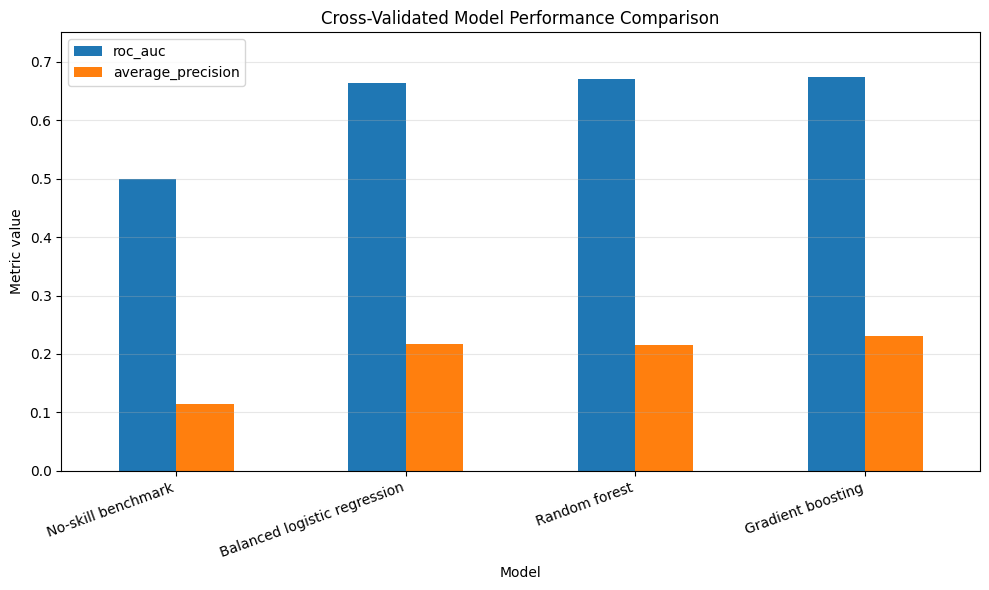

In [ ]:
# Create a professional comparison chart for the main ranking metrics

comparison_plot_data = (
    model_comparison_table
    .set_index("model")[
        [
            "roc_auc",
            "average_precision"
        ]
    ]
)

ax = comparison_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Cross-Validated Model Performance Comparison"
)

ax.set_xlabel("Model")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 0.75)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 6. Final Model Evaluation on the Protected Test Set

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

# Fit the selected model using the full development dataset
gradient_boosting_pipeline.fit(
    X_development_final,
    y_development_final
)

# Generate predictions for the protected test dataset
test_predicted_probabilities = (
    gradient_boosting_pipeline
    .predict_proba(X_test_final)[:, 1]
)

test_predicted_classes = (
    gradient_boosting_pipeline
    .predict(X_test_final)
)

# Calculate protected test-set performance
protected_test_results = pd.DataFrame({
    "model": [
        "Gradient boosting"
    ],
    "roc_auc": [
        roc_auc_score(
            y_test_final,
            test_predicted_probabilities
        )
    ],
    "average_precision": [
        average_precision_score(
            y_test_final,
            test_predicted_probabilities
        )
    ],
    "recall": [
        recall_score(
            y_test_final,
            test_predicted_classes
        )
    ],
    "precision": [
        precision_score(
            y_test_final,
            test_predicted_classes,
            zero_division=0
        )
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(
            y_test_final,
            test_predicted_classes
        )
    ]
}).round(3)

# Create a confusion matrix
test_confusion_matrix = confusion_matrix(
    y_test_final,
    test_predicted_classes
)

print("Protected test-set evaluation completed successfully.\n")

display(protected_test_results)

print("\nConfusion matrix:")
print(test_confusion_matrix)

print("\nPredicted positive encounters:")
print(test_predicted_classes.sum())

print("\nPercentage of encounters flagged as higher risk:")
print(
    round(
        test_predicted_classes.mean() * 100,
        2
    ),
    "%"
)

Protected test-set evaluation completed successfully.



,model,roc_auc,average_precision,recall,precision,balanced_accuracy
0,Gradient boosting,0.671,0.215,0.572,0.176,0.622



Confusion matrix:
[[11812  5737]
 [  916  1223]]

Predicted positive encounters:
6960

Percentage of encounters flagged as higher risk:
35.35 %


In [ ]:
from sklearn.metrics import f1_score

# Extract confusion-matrix components
true_negatives, false_positives, false_negatives, true_positives = (
    test_confusion_matrix.ravel()
)

# Calculate additional clinically useful metrics
specificity = true_negatives / (
    true_negatives + false_positives
)

negative_predictive_value = true_negatives / (
    true_negatives + false_negatives
)

f1 = f1_score(
    y_test_final,
    test_predicted_classes
)

test_prevalence = y_test_final.mean()

flagged_percentage = test_predicted_classes.mean()

# Create an expanded test-performance table
expanded_test_performance = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "Average precision",
        "Recall / Sensitivity",
        "Specificity",
        "Precision / Positive predictive value",
        "Negative predictive value",
        "F1 score",
        "Balanced accuracy",
        "Observed 30-day readmission rate",
        "Percentage flagged as higher risk"
    ],
    "value": [
        roc_auc_score(
            y_test_final,
            test_predicted_probabilities
        ),
        average_precision_score(
            y_test_final,
            test_predicted_probabilities
        ),
        recall_score(
            y_test_final,
            test_predicted_classes
        ),
        specificity,
        precision_score(
            y_test_final,
            test_predicted_classes,
            zero_division=0
        ),
        negative_predictive_value,
        f1,
        balanced_accuracy_score(
            y_test_final,
            test_predicted_classes
        ),
        test_prevalence,
        flagged_percentage
    ]
})

expanded_test_performance["value"] = (
    expanded_test_performance["value"]
    .round(3)
)

# Create a labelled confusion-matrix table
labelled_confusion_matrix = pd.DataFrame(
    test_confusion_matrix,
    index=[
        "Actually not readmitted",
        "Actually readmitted within 30 days"
    ],
    columns=[
        "Predicted lower risk",
        "Predicted higher risk"
    ]
)

print("Expanded protected test-set summary created successfully.\n")

display(expanded_test_performance)

print("\nLabelled confusion matrix:\n")

display(labelled_confusion_matrix)

Expanded protected test-set summary created successfully.



,metric,value
0,ROC-AUC,0.671
1,Average precision,0.215
2,Recall / Sensitivity,0.572
3,Specificity,0.673
4,Precision / Positive predictive value,0.176
5,Negative predictive value,0.928
6,F1 score,0.269
7,Balanced accuracy,0.622
8,Observed 30-day readmission rate,0.109
9,Percentage flagged as higher risk,0.354



Labelled confusion matrix:



,Predicted lower risk,Predicted higher risk
Actually not readmitted,11812,5737
Actually readmitted within 30 days,916,1223


## 7. Probability Calibration Assessment

Probability-calibration assessment completed successfully.

Observed 30-day readmission rate:
0.109

Mean predicted probability:
0.451

Brier score:
0.217

Calibration summary by probability group:


,predicted_probability,observed_readmission_rate
0,0.222,0.044
1,0.304,0.053
2,0.351,0.066
3,0.387,0.072
4,0.424,0.083
5,0.463,0.096
6,0.501,0.114
7,0.543,0.128
8,0.608,0.163
9,0.707,0.267


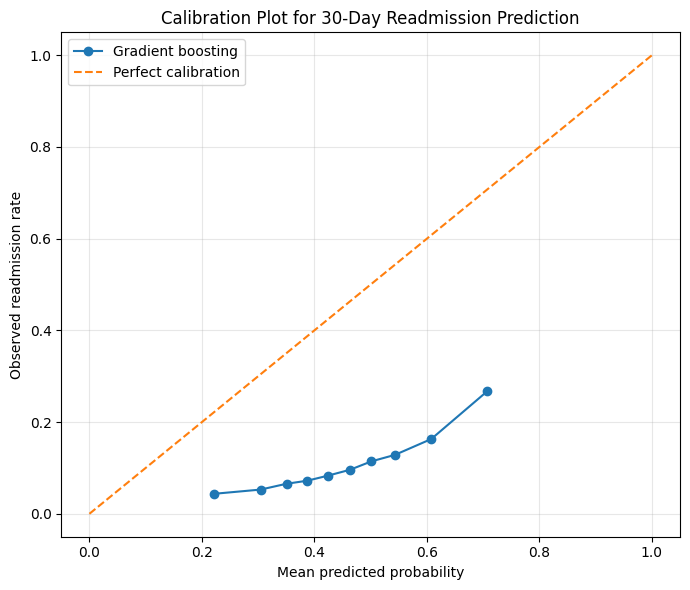

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Calculate overall calibration indicators
mean_predicted_probability = (
    test_predicted_probabilities.mean()
)

observed_readmission_rate = (
    y_test_final.mean()
)

brier_score = brier_score_loss(
    y_test_final,
    test_predicted_probabilities
)

print("Probability-calibration assessment completed successfully.")

print("\nObserved 30-day readmission rate:")
print(round(observed_readmission_rate, 3))

print("\nMean predicted probability:")
print(round(mean_predicted_probability, 3))

print("\nBrier score:")
print(round(brier_score, 3))

# Create quantile-based calibration bins
observed_probability, predicted_probability = (
    calibration_curve(
        y_test_final,
        test_predicted_probabilities,
        n_bins=10,
        strategy="quantile"
    )
)

calibration_summary = pd.DataFrame({
    "predicted_probability": predicted_probability,
    "observed_readmission_rate": observed_probability
}).round(3)

print("\nCalibration summary by probability group:")

display(calibration_summary)

# Create the calibration plot
plt.figure(figsize=(7, 6))

plt.plot(
    predicted_probability,
    observed_probability,
    marker="o",
    label="Gradient boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.title("Calibration Plot for 30-Day Readmission Prediction")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict

# Generate leakage-safe out-of-fold predicted probabilities
# using only the development dataset.
#
# Each encounter receives a prediction from a model that was
# trained on the other folds. Patient grouping remains protected.

development_oof_probabilities = cross_val_predict(
    estimator=gradient_boosting_pipeline,
    X=X_development_final,
    y=y_development_final,
    groups=groups_development_final,
    cv=group_cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

print("Leakage-safe out-of-fold probabilities created successfully.")

print("\nNumber of development encounters:")
print(len(y_development_final))

print("\nNumber of out-of-fold probabilities:")
print(len(development_oof_probabilities))

print("\nObserved development-set readmission rate:")
print(
    round(
        y_development_final.mean(),
        3
    )
)

print("\nMean out-of-fold predicted probability before calibration:")
print(
    round(
        development_oof_probabilities.mean(),
        3
    )
)

print("\nMinimum predicted probability:")
print(
    round(
        development_oof_probabilities.min(),
        3
    )
)

print("\nMaximum predicted probability:")
print(
    round(
        development_oof_probabilities.max(),
        3
    )
)

Leakage-safe out-of-fold probabilities created successfully.

Number of development encounters:
79655

Number of out-of-fold probabilities:
79655

Observed development-set readmission rate:
0.115

Mean out-of-fold predicted probability before calibration:
0.453

Minimum predicted probability:
0.048

Maximum predicted probability:
0.914


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create a helper function to convert probabilities into log-odds.
# Clipping prevents numerical problems near 0 and 1.
def convert_probability_to_logit(probabilities):
    clipped_probabilities = np.clip(
        probabilities,
        1e-6,
        1 - 1e-6
    )

    return np.log(
        clipped_probabilities /
        (1 - clipped_probabilities)
    )


# Convert leakage-safe development probabilities into log-odds
development_oof_logits = convert_probability_to_logit(
    development_oof_probabilities
).reshape(-1, 1)

# Fit a sigmoid calibration layer using development data only
sigmoid_calibrator = LogisticRegression(
    solver="lbfgs"
)

sigmoid_calibrator.fit(
    development_oof_logits,
    y_development_final
)

# Apply the calibration layer to the raw protected test probabilities
test_raw_logits = convert_probability_to_logit(
    test_predicted_probabilities
).reshape(-1, 1)

test_calibrated_probabilities = (
    sigmoid_calibrator
    .predict_proba(test_raw_logits)[:, 1]
)

print("Sigmoid calibration layer fitted successfully.")

print("\nCalibration model intercept:")
print(
    round(
        sigmoid_calibrator.intercept_[0],
        3
    )
)

print("\nCalibration model slope:")
print(
    round(
        sigmoid_calibrator.coef_[0][0],
        3
    )
)

print("\nObserved protected test-set readmission rate:")
print(
    round(
        y_test_final.mean(),
        3
    )
)

print("\nMean raw predicted probability before calibration:")
print(
    round(
        test_predicted_probabilities.mean(),
        3
    )
)

print("\nMean predicted probability after calibration:")
print(
    round(
        test_calibrated_probabilities.mean(),
        3
    )
)

Sigmoid calibration layer fitted successfully.

Calibration model intercept:
-1.981

Calibration model slope:
1.065

Observed protected test-set readmission rate:
0.109

Mean raw predicted probability before calibration:
0.451

Mean predicted probability after calibration:
0.114


Raw and calibrated probability comparison completed successfully.



,probability_version,mean_predicted_probability,observed_readmission_rate,brier_score,log_loss,roc_auc,average_precision
0,Raw gradient-boosting probabilities,0.451,0.109,0.217,0.623,0.671,0.215
1,Sigmoid-calibrated probabilities,0.114,0.109,0.093,0.325,0.671,0.215


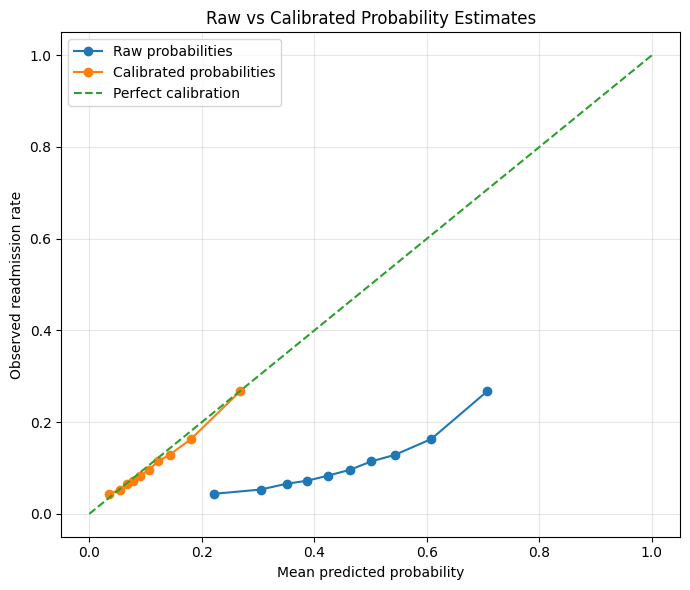

In [ ]:
from sklearn.metrics import log_loss

# Compare raw and calibrated probability performance
raw_brier_score = brier_score_loss(
    y_test_final,
    test_predicted_probabilities
)

calibrated_brier_score = brier_score_loss(
    y_test_final,
    test_calibrated_probabilities
)

raw_log_loss = log_loss(
    y_test_final,
    test_predicted_probabilities
)

calibrated_log_loss = log_loss(
    y_test_final,
    test_calibrated_probabilities
)

calibration_comparison_table = pd.DataFrame({
    "probability_version": [
        "Raw gradient-boosting probabilities",
        "Sigmoid-calibrated probabilities"
    ],
    "mean_predicted_probability": [
        test_predicted_probabilities.mean(),
        test_calibrated_probabilities.mean()
    ],
    "observed_readmission_rate": [
        y_test_final.mean(),
        y_test_final.mean()
    ],
    "brier_score": [
        raw_brier_score,
        calibrated_brier_score
    ],
    "log_loss": [
        raw_log_loss,
        calibrated_log_loss
    ],
    "roc_auc": [
        roc_auc_score(
            y_test_final,
            test_predicted_probabilities
        ),
        roc_auc_score(
            y_test_final,
            test_calibrated_probabilities
        )
    ],
    "average_precision": [
        average_precision_score(
            y_test_final,
            test_predicted_probabilities
        ),
        average_precision_score(
            y_test_final,
            test_calibrated_probabilities
        )
    ]
}).round(3)

print("Raw and calibrated probability comparison completed successfully.\n")

display(calibration_comparison_table)

# Create calibration curves
raw_observed, raw_predicted = calibration_curve(
    y_test_final,
    test_predicted_probabilities,
    n_bins=10,
    strategy="quantile"
)

calibrated_observed, calibrated_predicted = calibration_curve(
    y_test_final,
    test_calibrated_probabilities,
    n_bins=10,
    strategy="quantile"
)

# Create a comparison chart
plt.figure(figsize=(7, 6))

plt.plot(
    raw_predicted,
    raw_observed,
    marker="o",
    label="Raw probabilities"
)

plt.plot(
    calibrated_predicted,
    calibrated_observed,
    marker="o",
    label="Calibrated probabilities"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.title("Raw vs Calibrated Probability Estimates")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Apply the fitted sigmoid calibration layer to the
# leakage-safe out-of-fold development probabilities.

development_calibrated_probabilities = (
    sigmoid_calibrator
    .predict_proba(
        development_oof_logits
    )[:, 1]
)

print("Calibrated development-set probabilities created successfully.")

print("\nObserved development-set readmission rate:")
print(
    round(
        y_development_final.mean(),
        3
    )
)

print("\nMean calibrated development-set probability:")
print(
    round(
        development_calibrated_probabilities.mean(),
        3
    )
)

print("\nMinimum calibrated probability:")
print(
    round(
        development_calibrated_probabilities.min(),
        3
    )
)

print("\nMaximum calibrated probability:")
print(
    round(
        development_calibrated_probabilities.max(),
        3
    )
)

Calibrated development-set probabilities created successfully.

Observed development-set readmission rate:
0.115

Mean calibrated development-set probability:
0.115

Minimum calibrated probability:
0.006

Maximum calibrated probability:
0.63


In [ ]:
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

# Define candidate thresholds for practical comparison
candidate_thresholds = [
    0.05,
    0.075,
    0.10,
    0.125,
    0.15,
    0.175,
    0.20,
    0.25,
    0.30
]

threshold_results = []

for threshold in candidate_thresholds:

    predicted_classes = (
        development_calibrated_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_development_final,
        predicted_classes
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    positive_predictive_value = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    threshold_results.append({
        "threshold": threshold,
        "flagged_percentage": (
            predicted_classes.mean() * 100
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision_ppv": positive_predictive_value,
        "negative_predictive_value": negative_predictive_value,
        "f1_score": f1_score(
            y_development_final,
            predicted_classes,
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_development_final,
            predicted_classes
        ),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_comparison_table = pd.DataFrame(
    threshold_results
)

print("Candidate-threshold comparison completed successfully.\n")

display(
    threshold_comparison_table.round(3)
)

Candidate-threshold comparison completed successfully.



,threshold,flagged_percentage,sensitivity,specificity,precision_ppv,negative_predictive_value,f1_score,balanced_accuracy,true_positives,false_positives,false_negatives,true_negatives
0,0.050,88.297,0.958,0.127,0.125,0.958,0.221,0.542,8786,61547,389,8933
1,0.075,67.815,0.845,0.344,0.143,0.944,0.245,0.594,7749,46269,1426,24211
2,0.100,49.064,0.699,0.537,0.164,0.932,0.266,0.618,6417,32665,2758,37815
3,0.125,33.628,0.554,0.692,0.190,0.923,0.283,0.623,5086,21700,4089,48780
4,0.150,22.748,0.431,0.799,0.218,0.915,0.290,0.615,3954,14166,5221,56314
5,0.175,16.343,0.340,0.860,0.240,0.909,0.281,0.600,3123,9895,6052,60585
6,0.200,10.691,0.251,0.912,0.270,0.903,0.260,0.581,2299,6217,6876,64263
7,0.250,4.350,0.127,0.967,0.337,0.895,0.185,0.547,1168,2297,8007,68183
8,0.300,2.458,0.086,0.983,0.403,0.892,0.142,0.535,789,1169,8386,69311


In [ ]:
# Select the threshold using development-set performance only
selected_threshold = 0.125

# Apply the selected threshold once to the protected test set
test_calibrated_classes = (
    test_calibrated_probabilities >= selected_threshold
).astype(int)

# Create the protected test-set confusion matrix
calibrated_test_confusion_matrix = confusion_matrix(
    y_test_final,
    test_calibrated_classes
)

tn, fp, fn, tp = calibrated_test_confusion_matrix.ravel()

# Calculate threshold-specific test-set metrics
calibrated_test_threshold_summary = pd.DataFrame({
    "metric": [
        "Selected threshold",
        "Percentage flagged as higher risk",
        "Recall / Sensitivity",
        "Specificity",
        "Precision / Positive predictive value",
        "Negative predictive value",
        "F1 score",
        "Balanced accuracy",
        "True positives",
        "False positives",
        "False negatives",
        "True negatives"
    ],
    "value": [
        selected_threshold,
        test_calibrated_classes.mean() * 100,
        tp / (tp + fn),
        tn / (tn + fp),
        tp / (tp + fp),
        tn / (tn + fn),
        f1_score(
            y_test_final,
            test_calibrated_classes,
            zero_division=0
        ),
        balanced_accuracy_score(
            y_test_final,
            test_calibrated_classes
        ),
        tp,
        fp,
        fn,
        tn
    ]
})

calibrated_test_threshold_summary["value"] = (
    calibrated_test_threshold_summary["value"]
    .round(3)
)

# Create a labelled confusion matrix
labelled_calibrated_confusion_matrix = pd.DataFrame(
    calibrated_test_confusion_matrix,
    index=[
        "Actually not readmitted",
        "Actually readmitted within 30 days"
    ],
    columns=[
        "Predicted lower risk",
        "Predicted higher risk"
    ]
)

print("Selected threshold applied to the protected test set successfully.\n")

display(calibrated_test_threshold_summary)

print("\nLabelled confusion matrix:\n")

display(labelled_calibrated_confusion_matrix)

Selected threshold applied to the protected test set successfully.



,metric,value
0,Selected threshold,0.125
1,Percentage flagged as higher risk,33.025
2,Recall / Sensitivity,0.547
3,Specificity,0.696
4,Precision / Positive predictive value,0.180
5,Negative predictive value,0.927
6,F1 score,0.271
7,Balanced accuracy,0.622
8,True positives,1171.000
9,False positives,5331.000



Labelled confusion matrix:



,Predicted lower risk,Predicted higher risk
Actually not readmitted,12218,5331
Actually readmitted within 30 days,968,1171


In [ ]:
# Extract the development-set results for the selected threshold
selected_development_row = (
    threshold_comparison_table[
        np.isclose(
            threshold_comparison_table["threshold"],
            selected_threshold
        )
    ]
    .iloc[0]
)

# Create a clean development-versus-test comparison table
threshold_generalization_table = pd.DataFrame({
    "dataset": [
        "Leakage-safe development predictions",
        "Protected test set"
    ],
    "selected_threshold": [
        selected_threshold,
        selected_threshold
    ],
    "flagged_percentage": [
        selected_development_row["flagged_percentage"],
        test_calibrated_classes.mean() * 100
    ],
    "sensitivity": [
        selected_development_row["sensitivity"],
        tp / (tp + fn)
    ],
    "specificity": [
        selected_development_row["specificity"],
        tn / (tn + fp)
    ],
    "precision_ppv": [
        selected_development_row["precision_ppv"],
        tp / (tp + fp)
    ],
    "negative_predictive_value": [
        selected_development_row["negative_predictive_value"],
        tn / (tn + fn)
    ],
    "f1_score": [
        selected_development_row["f1_score"],
        f1_score(
            y_test_final,
            test_calibrated_classes,
            zero_division=0
        )
    ],
    "balanced_accuracy": [
        selected_development_row["balanced_accuracy"],
        balanced_accuracy_score(
            y_test_final,
            test_calibrated_classes
        )
    ]
}).round(3)

print("Threshold-generalization table created successfully.\n")

display(threshold_generalization_table)

Threshold-generalization table created successfully.



,dataset,selected_threshold,flagged_percentage,sensitivity,specificity,precision_ppv,negative_predictive_value,f1_score,balanced_accuracy
0,Leakage-safe development predictions,0.125,33.628,0.554,0.692,0.19,0.923,0.283,0.623
1,Protected test set,0.125,33.025,0.547,0.696,0.18,0.927,0.271,0.622


## 8. Model Interpretation and Predictor Importance

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit

# Create an internal patient-level split using development data only.
# This split is used for model interpretation, not final evaluation.

interpretation_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=123
)

interpretation_train_index, interpretation_holdout_index = next(
    interpretation_split.split(
        X_development_final,
        y_development_final,
        groups=groups_development_final
    )
)

# Create interpretation training and holdout datasets
X_interpretation_train = X_development_final.iloc[
    interpretation_train_index
].copy()

y_interpretation_train = y_development_final.iloc[
    interpretation_train_index
].copy()

groups_interpretation_train = groups_development_final.iloc[
    interpretation_train_index
].copy()

X_interpretation_holdout = X_development_final.iloc[
    interpretation_holdout_index
].copy()

y_interpretation_holdout = y_development_final.iloc[
    interpretation_holdout_index
].copy()

groups_interpretation_holdout = groups_development_final.iloc[
    interpretation_holdout_index
].copy()

# Verify that patients do not overlap
interpretation_overlap = set(
    groups_interpretation_train
).intersection(
    set(groups_interpretation_holdout)
)

print("Internal interpretation holdout created successfully.")

print("\nInterpretation-training encounters:")
print(X_interpretation_train.shape[0])

print("\nInterpretation-holdout encounters:")
print(X_interpretation_holdout.shape[0])

print("\nPatients appearing in both interpretation datasets:")
print(len(interpretation_overlap))

print("\nInterpretation-training readmission rate:")
print(
    round(
        y_interpretation_train.mean() * 100,
        2
    ),
    "%"
)

print("\nInterpretation-holdout readmission rate:")
print(
    round(
        y_interpretation_holdout.mean() * 100,
        2
    ),
    "%"
)

Internal interpretation holdout created successfully.

Interpretation-training encounters:
63794

Interpretation-holdout encounters:
15861

Patients appearing in both interpretation datasets:
0

Interpretation-training readmission rate:
11.44 %

Interpretation-holdout readmission rate:
11.82 %


In [ ]:
from sklearn.base import clone

# Create a separate copy of the selected gradient-boosting pipeline
# for the interpretation stage only.
interpretation_model = clone(
    gradient_boosting_pipeline
)

# Fit the interpretation model using only the internal
# development-set training portion.
interpretation_model.fit(
    X_interpretation_train,
    y_interpretation_train
)

# Generate holdout probabilities for a quick quality check
interpretation_holdout_probabilities = (
    interpretation_model
    .predict_proba(
        X_interpretation_holdout
    )[:, 1]
)

# Evaluate discrimination on the internal interpretation holdout
interpretation_holdout_roc_auc = roc_auc_score(
    y_interpretation_holdout,
    interpretation_holdout_probabilities
)

interpretation_holdout_average_precision = (
    average_precision_score(
        y_interpretation_holdout,
        interpretation_holdout_probabilities
    )
)

print("Interpretation model fitted successfully.")

print("\nInternal interpretation-holdout ROC-AUC:")
print(
    round(
        interpretation_holdout_roc_auc,
        3
    )
)

print("\nInternal interpretation-holdout average precision:")
print(
    round(
        interpretation_holdout_average_precision,
        3
    )
)

print("\nObserved interpretation-holdout readmission rate:")
print(
    round(
        y_interpretation_holdout.mean(),
        3
    )
)

Interpretation model fitted successfully.

Internal interpretation-holdout ROC-AUC:
0.668

Internal interpretation-holdout average precision:
0.227

Observed interpretation-holdout readmission rate:
0.118


In [ ]:
from sklearn.inspection import permutation_importance

# Calculate predictor importance on unseen development patients.
# ROC-AUC is used because we want to measure each predictor's
# contribution to risk discrimination.

permutation_results = permutation_importance(
    estimator=interpretation_model,
    X=X_interpretation_holdout,
    y=y_interpretation_holdout,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

# Create a clean importance table
permutation_importance_table = pd.DataFrame({
    "predictor": X_interpretation_holdout.columns,
    "mean_roc_auc_decrease": permutation_results.importances_mean,
    "standard_deviation": permutation_results.importances_std
})

# Sort predictors from most to least influential
permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        by="mean_roc_auc_decrease",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Permutation importance calculated successfully.\n")

print("Top 15 predictors by mean ROC-AUC decrease:\n")

display(
    permutation_importance_table
    .head(15)
    .round(4)
)

Permutation importance calculated successfully.

Top 15 predictors by mean ROC-AUC decrease:



,predictor,mean_roc_auc_decrease,standard_deviation
0,number_inpatient,0.0845,0.0050
1,discharge_disposition_id,0.0448,0.0022
2,diag_1_group,0.0056,0.0009
3,payer_code,0.0040,0.0011
4,medical_specialty,0.0039,0.0005
5,number_diagnoses,0.0035,0.0003
6,age_midpoint,0.0032,0.0006
7,number_emergency,0.0024,0.0016
8,metformin,0.0023,0.0005
9,num_medications,0.0016,0.0006


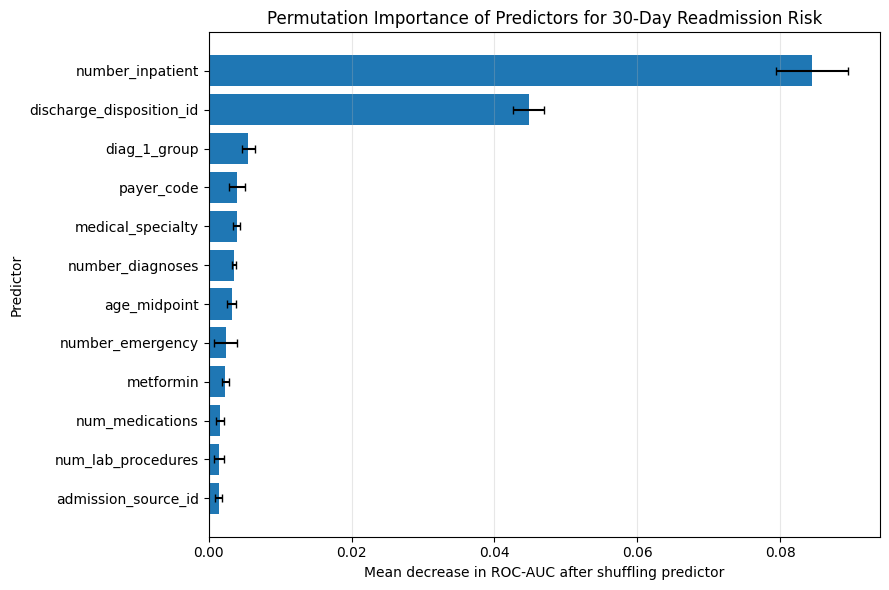

Predictor-importance chart created and saved successfully.


In [ ]:
# Select the 12 most influential predictors
top_predictors_for_plot = (
    permutation_importance_table
    .head(12)
    .sort_values(
        by="mean_roc_auc_decrease",
        ascending=True
    )
)

# Create a professional predictor-importance chart
plt.figure(figsize=(9, 6))

plt.barh(
    top_predictors_for_plot["predictor"],
    top_predictors_for_plot["mean_roc_auc_decrease"],
    xerr=top_predictors_for_plot["standard_deviation"],
    capsize=3
)

plt.title(
    "Permutation Importance of Predictors for 30-Day Readmission Risk"
)

plt.xlabel(
    "Mean decrease in ROC-AUC after shuffling predictor"
)

plt.ylabel(
    "Predictor"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

# Save a high-resolution copy for the portfolio
plt.savefig(
    "readmission_predictor_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Predictor-importance chart created and saved successfully.")

Observed readmission risk by prior inpatient utilization:



,prior_inpatient_group,encounters,readmissions_within_30_days,observed_readmission_rate_percentage
0,0,10585,928,8.77
1,1,3022,423,14.00
2,2,1159,232,20.02
3,3,529,117,22.12
4,4 or more,566,175,30.92


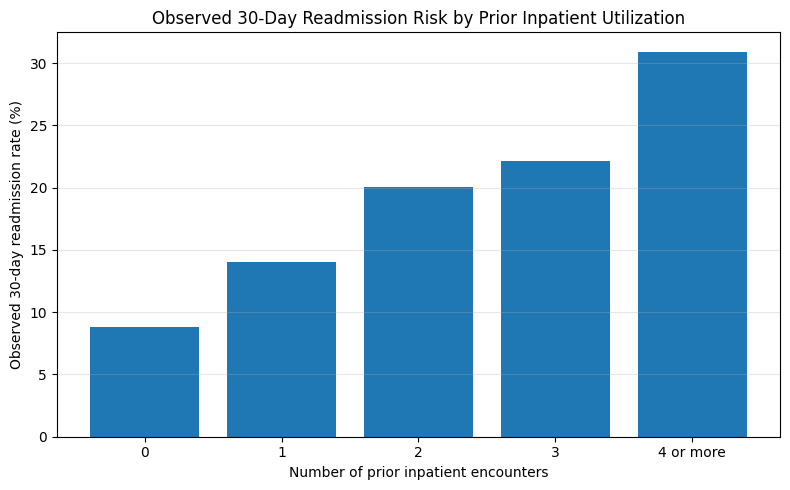

Prior-inpatient-utilization interpretation chart created and saved successfully.


In [ ]:
# Examine the relationship between prior inpatient utilization
# and observed 30-day readmission risk using unseen development patients.

utilization_interpretation_data = pd.DataFrame({
    "number_inpatient": (
        X_interpretation_holdout["number_inpatient"]
        .reset_index(drop=True)
    ),
    "readmitted_30_days": (
        y_interpretation_holdout
        .reset_index(drop=True)
    )
})

# Group prior inpatient encounters into interpretable categories
def group_prior_inpatient_utilization(value):
    if value == 0:
        return "0"
    elif value == 1:
        return "1"
    elif value == 2:
        return "2"
    elif value == 3:
        return "3"
    else:
        return "4 or more"

utilization_interpretation_data[
    "prior_inpatient_group"
] = (
    utilization_interpretation_data["number_inpatient"]
    .apply(group_prior_inpatient_utilization)
)

# Define the logical category order
utilization_category_order = [
    "0",
    "1",
    "2",
    "3",
    "4 or more"
]

# Summarize observed readmission risk
utilization_risk_table = (
    utilization_interpretation_data
    .groupby(
        "prior_inpatient_group",
        observed=False
    )
    .agg(
        encounters=("readmitted_30_days", "size"),
        readmissions_within_30_days=(
            "readmitted_30_days",
            "sum"
        ),
        observed_readmission_rate=(
            "readmitted_30_days",
            "mean"
        )
    )
    .reindex(utilization_category_order)
    .reset_index()
)

utilization_risk_table[
    "observed_readmission_rate_percentage"
] = (
    utilization_risk_table["observed_readmission_rate"]
    * 100
).round(2)

print(
    "Observed readmission risk by prior inpatient utilization:\n"
)

display(
    utilization_risk_table[
        [
            "prior_inpatient_group",
            "encounters",
            "readmissions_within_30_days",
            "observed_readmission_rate_percentage"
        ]
    ]
)

# Create a professional interpretation chart
plt.figure(figsize=(8, 5))

plt.bar(
    utilization_risk_table[
        "prior_inpatient_group"
    ],
    utilization_risk_table[
        "observed_readmission_rate_percentage"
    ]
)

plt.title(
    "Observed 30-Day Readmission Risk by Prior Inpatient Utilization"
)

plt.xlabel(
    "Number of prior inpatient encounters"
)

plt.ylabel(
    "Observed 30-day readmission rate (%)"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "readmission_risk_by_prior_inpatient_utilization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Prior-inpatient-utilization interpretation chart "
    "created and saved successfully."
)

Observed readmission risk with 95% confidence intervals:



,prior_inpatient_group,encounters,readmissions_within_30_days,observed_readmission_rate_percentage,ci_lower_percentage,ci_upper_percentage
0,0,10585,928,8.77,8.23,9.31
1,1,3022,423,14.00,12.76,15.23
2,2,1159,232,20.02,17.71,22.32
3,3,529,117,22.12,18.58,25.65
4,4 or more,566,175,30.92,27.11,34.73


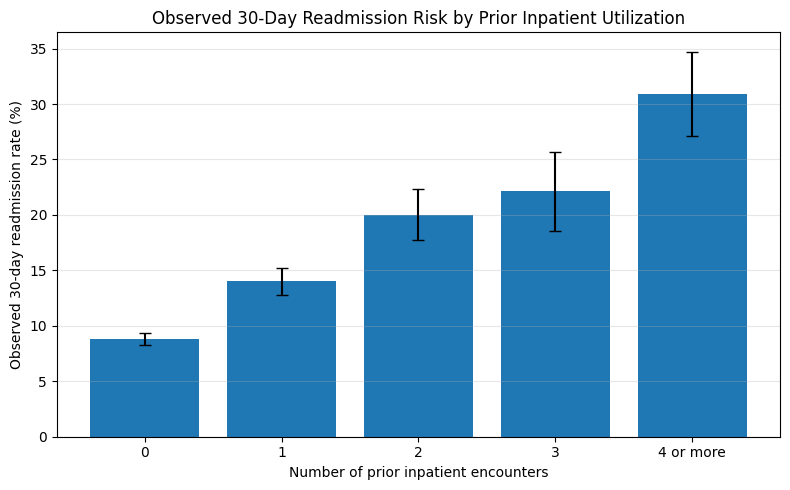

Confidence-interval chart created and saved successfully.


In [56]:
# Add approximate 95% confidence intervals for the observed
# readmission rates in each utilization group.

utilization_risk_table[
    "standard_error"
] = np.sqrt(
    (
        utilization_risk_table["observed_readmission_rate"]
        * (
            1
            - utilization_risk_table[
                "observed_readmission_rate"
            ]
        )
    )
    / utilization_risk_table["encounters"]
)

utilization_risk_table[
    "ci_lower"
] = (
    utilization_risk_table["observed_readmission_rate"]
    - 1.96
    * utilization_risk_table["standard_error"]
).clip(lower=0)

utilization_risk_table[
    "ci_upper"
] = (
    utilization_risk_table["observed_readmission_rate"]
    + 1.96
    * utilization_risk_table["standard_error"]
).clip(upper=1)

# Convert proportions into percentages for reporting
utilization_risk_table[
    "ci_lower_percentage"
] = (
    utilization_risk_table["ci_lower"] * 100
).round(2)

utilization_risk_table[
    "ci_upper_percentage"
] = (
    utilization_risk_table["ci_upper"] * 100
).round(2)

print(
    "Observed readmission risk with 95% confidence intervals:\n"
)

display(
    utilization_risk_table[
        [
            "prior_inpatient_group",
            "encounters",
            "readmissions_within_30_days",
            "observed_readmission_rate_percentage",
            "ci_lower_percentage",
            "ci_upper_percentage"
        ]
    ]
)

# Create a portfolio-ready chart with confidence intervals
plt.figure(figsize=(8, 5))

plt.bar(
    utilization_risk_table[
        "prior_inpatient_group"
    ],
    utilization_risk_table[
        "observed_readmission_rate_percentage"
    ],
    yerr=[
        utilization_risk_table[
            "observed_readmission_rate_percentage"
        ]
        - utilization_risk_table[
            "ci_lower_percentage"
        ],
        utilization_risk_table[
            "ci_upper_percentage"
        ]
        - utilization_risk_table[
            "observed_readmission_rate_percentage"
        ]
    ],
    capsize=4
)

plt.title(
    "Observed 30-Day Readmission Risk by Prior Inpatient Utilization"
)

plt.xlabel(
    "Number of prior inpatient encounters"
)

plt.ylabel(
    "Observed 30-day readmission rate (%)"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "readmission_risk_by_prior_inpatient_utilization_with_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confidence-interval chart created and saved successfully."
)

In [57]:
# Create a readable mapping for discharge-disposition categories
discharge_disposition_mapping = {
    1: "Discharged to home",
    2: "Transferred to short-term hospital",
    3: "Transferred to skilled nursing facility",
    4: "Transferred to intermediate care facility",
    5: "Transferred to another inpatient-care institution",
    6: "Home with home-health service",
    7: "Left against medical advice",
    8: "Home under care of home IV provider",
    9: "Admitted as inpatient to same hospital",
    10: "Neonate transferred for aftercare",
    12: "Still patient / expected outpatient return",
    15: "Transferred to Medicare-approved swing bed",
    16: "Referred to another institution for outpatient services",
    17: "Referred to this institution for outpatient services",
    18: "NULL / not recorded",
    22: "Transferred to rehabilitation facility",
    23: "Transferred to long-term care hospital",
    24: "Transferred to Medicaid-certified nursing facility",
    25: "Not mapped",
    26: "Unknown / invalid",
    27: "Transferred to federal health-care facility",
    28: "Transferred to psychiatric hospital",
    29: "Transferred to critical-access hospital",
    30: "Transferred to other health-care institution"
}

# Create an interpretation dataset using unseen development patients only
disposition_interpretation_data = pd.DataFrame({
    "discharge_disposition_id": (
        X_interpretation_holdout["discharge_disposition_id"]
        .reset_index(drop=True)
    ),
    "readmitted_30_days": (
        y_interpretation_holdout
        .reset_index(drop=True)
    )
})

# Add readable category descriptions
disposition_interpretation_data[
    "discharge_disposition_description"
] = (
    disposition_interpretation_data[
        "discharge_disposition_id"
    ]
    .map(discharge_disposition_mapping)
    .fillna("Other / unmapped")
)

# Summarize observed readmission risk
disposition_risk_table = (
    disposition_interpretation_data
    .groupby(
        [
            "discharge_disposition_id",
            "discharge_disposition_description"
        ],
        observed=False
    )
    .agg(
        encounters=("readmitted_30_days", "size"),
        readmissions_within_30_days=(
            "readmitted_30_days",
            "sum"
        ),
        observed_readmission_rate=(
            "readmitted_30_days",
            "mean"
        )
    )
    .reset_index()
)

disposition_risk_table[
    "observed_readmission_rate_percentage"
] = (
    disposition_risk_table[
        "observed_readmission_rate"
    ] * 100
).round(2)

# Keep categories with at least 100 encounters for stable interpretation
disposition_risk_table_stable = (
    disposition_risk_table[
        disposition_risk_table["encounters"] >= 100
    ]
    .sort_values(
        by="observed_readmission_rate_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Observed readmission risk by discharge disposition "
    "(categories with at least 100 encounters):\n"
)

display(
    disposition_risk_table_stable[
        [
            "discharge_disposition_id",
            "discharge_disposition_description",
            "encounters",
            "readmissions_within_30_days",
            "observed_readmission_rate_percentage"
        ]
    ]
)

Observed readmission risk by discharge disposition (categories with at least 100 encounters):



,discharge_disposition_id,discharge_disposition_description,encounters,readmissions_within_30_days,observed_readmission_rate_percentage
0,22,Transferred to rehabilitation facility,291,81,27.84
1,5,Transferred to another inpatient-care institution,187,39,20.86
2,2,Transferred to short-term hospital,335,59,17.61
3,3,Transferred to skilled nursing facility,2297,334,14.54
4,4,Transferred to intermediate care facility,158,21,13.29
5,6,Home with home-health service,2091,277,13.25
6,18,NULL / not recorded,548,65,11.86
7,1,Discharged to home,9553,934,9.78
8,25,Not mapped,159,15,9.43


Discharge-disposition risk with Wilson 95% confidence intervals:



,discharge_disposition_description,encounters,readmissions_within_30_days,observed_readmission_rate_percentage,ci_lower_percentage,ci_upper_percentage
0,Transferred to rehabilitation facility,291,81,27.84,23.00,33.25
1,Transferred to another inpatient-care institution,187,39,20.86,15.65,27.24
2,Transferred to short-term hospital,335,59,17.61,13.91,22.05
3,Transferred to skilled nursing facility,2297,334,14.54,13.16,16.04
4,Transferred to intermediate care facility,158,21,13.29,8.86,19.46
5,Home with home-health service,2091,277,13.25,11.86,14.77
6,NULL / not recorded,548,65,11.86,9.42,14.84
7,Discharged to home,9553,934,9.78,9.20,10.39
8,Not mapped,159,15,9.43,5.80,14.98


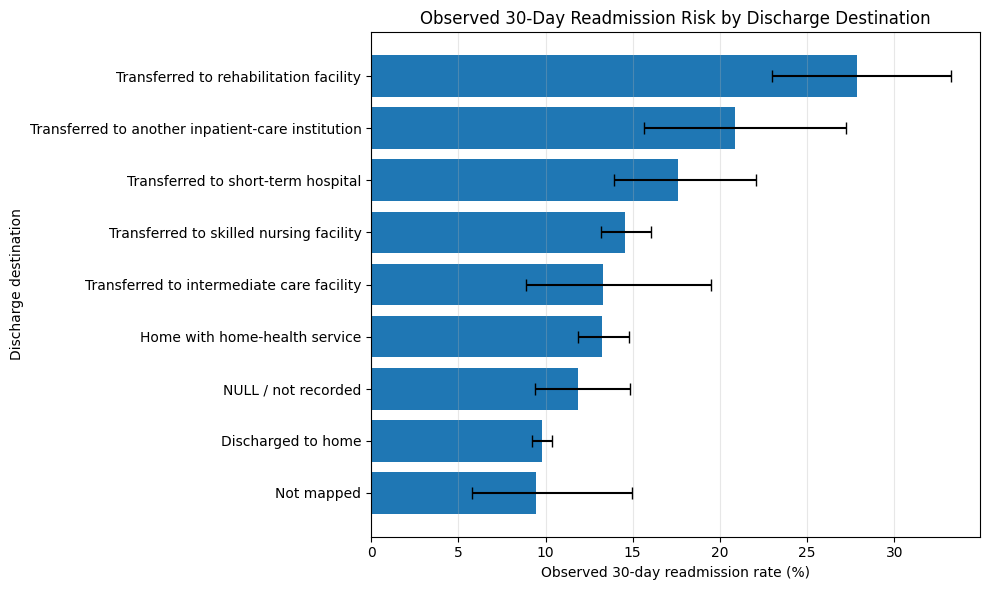

Discharge-destination confidence-interval chart created and saved successfully.


In [58]:
# Calculate Wilson 95% confidence intervals for each discharge group

z_value = 1.96

def calculate_wilson_interval(successes, total, z=1.96):
    """
    Calculate a Wilson confidence interval for a proportion.
    """
    proportion = successes / total

    denominator = 1 + (z ** 2 / total)

    centre = (
        proportion
        + (z ** 2 / (2 * total))
    ) / denominator

    margin = (
        z
        * np.sqrt(
            (
                proportion * (1 - proportion) / total
            )
            + (
                z ** 2 / (4 * total ** 2)
            )
        )
    ) / denominator

    return centre - margin, centre + margin


# Add confidence intervals to the stable interpretation table
wilson_intervals = disposition_risk_table_stable.apply(
    lambda row: calculate_wilson_interval(
        successes=row["readmissions_within_30_days"],
        total=row["encounters"],
        z=z_value
    ),
    axis=1
)

disposition_risk_table_stable[
    "ci_lower_percentage"
] = [
    lower_bound * 100
    for lower_bound, upper_bound in wilson_intervals
]

disposition_risk_table_stable[
    "ci_upper_percentage"
] = [
    upper_bound * 100
    for lower_bound, upper_bound in wilson_intervals
]

# Round values for the reporting table
disposition_risk_table_stable[
    "ci_lower_percentage"
] = (
    disposition_risk_table_stable[
        "ci_lower_percentage"
    ]
    .round(2)
)

disposition_risk_table_stable[
    "ci_upper_percentage"
] = (
    disposition_risk_table_stable[
        "ci_upper_percentage"
    ]
    .round(2)
)

print(
    "Discharge-disposition risk with Wilson 95% confidence intervals:\n"
)

display(
    disposition_risk_table_stable[
        [
            "discharge_disposition_description",
            "encounters",
            "readmissions_within_30_days",
            "observed_readmission_rate_percentage",
            "ci_lower_percentage",
            "ci_upper_percentage"
        ]
    ]
)

# Prepare a readable horizontal chart
disposition_plot_data = (
    disposition_risk_table_stable
    .sort_values(
        by="observed_readmission_rate_percentage",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    disposition_plot_data[
        "discharge_disposition_description"
    ],
    disposition_plot_data[
        "observed_readmission_rate_percentage"
    ],
    xerr=[
        disposition_plot_data[
            "observed_readmission_rate_percentage"
        ]
        - disposition_plot_data[
            "ci_lower_percentage"
        ],
        disposition_plot_data[
            "ci_upper_percentage"
        ]
        - disposition_plot_data[
            "observed_readmission_rate_percentage"
        ]
    ],
    capsize=4
)

plt.title(
    "Observed 30-Day Readmission Risk by Discharge Destination"
)

plt.xlabel(
    "Observed 30-day readmission rate (%)"
)

plt.ylabel(
    "Discharge destination"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "readmission_risk_by_discharge_destination_with_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Discharge-destination confidence-interval chart "
    "created and saved successfully."
)

### Interpretation of the Two Most Influential Predictors

Permutation importance identified prior inpatient utilization (`number_inpatient`) and discharge destination (`discharge_disposition_id`) as the two strongest contributors to 30-day readmission-risk discrimination.

Prior inpatient utilization showed a clear graded relationship with the outcome. The observed readmission rate increased from 8.77% among encounters with no prior inpatient admissions to 30.92% among encounters with four or more prior admissions.

Discharge destination also provided meaningful information in the at-discharge risk model. Encounters involving transfer to rehabilitation facilities or continued institutional care showed higher observed readmission rates than routine discharge to home.

These results should be interpreted as predictive associations rather than causal effects. Prior inpatient utilization and discharge destination may reflect underlying differences in clinical complexity, instability, functional needs, or care-transition requirements.


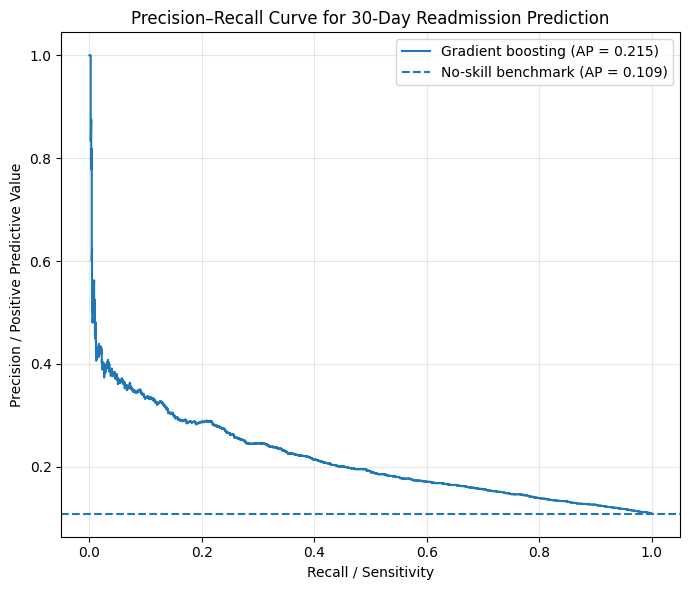

Precision–recall curve created and saved successfully.

Protected test-set average precision:
0.215

No-skill benchmark:
0.109


In [59]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Calculate the precision-recall curve using the calibrated
# protected test-set probabilities.
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test_final,
        test_calibrated_probabilities
    )
)

test_average_precision = average_precision_score(
    y_test_final,
    test_calibrated_probabilities
)

no_skill_average_precision = y_test_final.mean()

# Create a professional precision-recall curve
plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Gradient boosting (AP = {test_average_precision:.3f})"
)

plt.axhline(
    y=no_skill_average_precision,
    linestyle="--",
    label=f"No-skill benchmark (AP = {no_skill_average_precision:.3f})"
)

plt.title(
    "Precision–Recall Curve for 30-Day Readmission Prediction"
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision / Positive Predictive Value")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "readmission_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Precision–recall curve created and saved successfully.")

print("\nProtected test-set average precision:")
print(round(test_average_precision, 3))

print("\nNo-skill benchmark:")
print(round(no_skill_average_precision, 3))

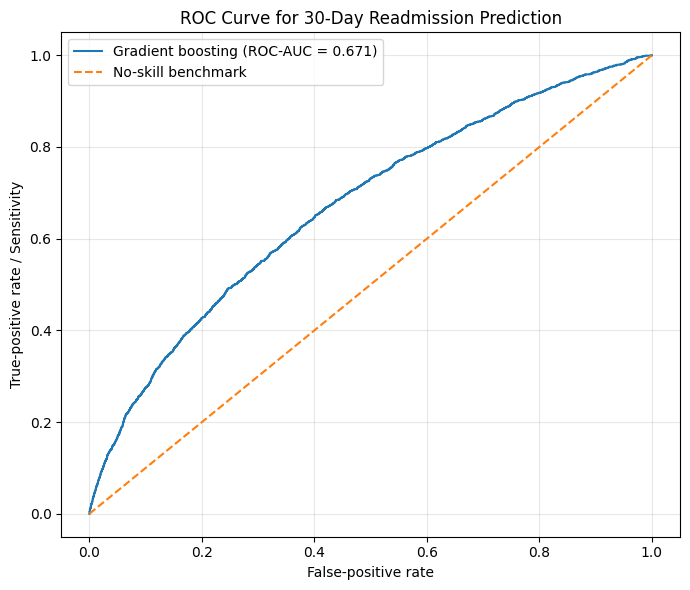

ROC curve created and saved successfully.

Protected test-set ROC-AUC:
0.671


In [60]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Calculate the ROC curve using calibrated protected test-set probabilities
false_positive_rate, true_positive_rate, roc_thresholds = (
    roc_curve(
        y_test_final,
        test_calibrated_probabilities
    )
)

test_roc_auc = roc_auc_score(
    y_test_final,
    test_calibrated_probabilities
)

# Create a professional ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Gradient boosting (ROC-AUC = {test_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill benchmark"
)

plt.title(
    "ROC Curve for 30-Day Readmission Prediction"
)

plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate / Sensitivity")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "readmission_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve created and saved successfully.")

print("\nProtected test-set ROC-AUC:")
print(round(test_roc_auc, 3))

## 9. Consolidated Portfolio Results

In [61]:
# Recalculate the final threshold-specific confusion matrix
# so the consolidated results remain fully reproducible.

final_confusion_matrix = confusion_matrix(
    y_test_final,
    test_calibrated_classes
)

tn, fp, fn, tp = final_confusion_matrix.ravel()

# Create a consolidated performance table
portfolio_performance_summary = pd.DataFrame({
    "metric": [
        "Eligible development encounters",
        "Eligible protected test encounters",
        "Unique patients in development set",
        "Unique patients in protected test set",
        "Patients shared across development and test sets",
        "Protected test-set readmission prevalence",
        "Cross-validated ROC-AUC: balanced logistic regression",
        "Cross-validated ROC-AUC: random forest",
        "Cross-validated ROC-AUC: gradient boosting",
        "Protected test-set ROC-AUC: gradient boosting",
        "Protected test-set average precision",
        "No-skill average-precision benchmark",
        "Raw probability Brier score",
        "Calibrated probability Brier score",
        "Raw probability log loss",
        "Calibrated probability log loss",
        "Selected calibrated risk threshold",
        "Percentage flagged as higher risk",
        "Sensitivity at selected threshold",
        "Specificity at selected threshold",
        "Precision / positive predictive value",
        "Negative predictive value",
        "Balanced accuracy",
        "True positives",
        "False positives",
        "False negatives",
        "True negatives"
    ],
    "value": [
        len(X_development_final),
        len(X_test_final),
        groups_development_final.nunique(),
        groups_test_final.nunique(),
        len(
            set(groups_development_final).intersection(
                set(groups_test_final)
            )
        ),
        y_test_final.mean(),
        baseline_cv_summary["roc_auc"].mean(),
        random_forest_cv_summary["roc_auc"].mean(),
        gradient_boosting_cv_summary["roc_auc"].mean(),
        roc_auc_score(
            y_test_final,
            test_calibrated_probabilities
        ),
        average_precision_score(
            y_test_final,
            test_calibrated_probabilities
        ),
        y_test_final.mean(),
        raw_brier_score,
        calibrated_brier_score,
        raw_log_loss,
        calibrated_log_loss,
        selected_threshold,
        test_calibrated_classes.mean() * 100,
        tp / (tp + fn),
        tn / (tn + fp),
        tp / (tp + fp),
        tn / (tn + fn),
        balanced_accuracy_score(
            y_test_final,
            test_calibrated_classes
        ),
        tp,
        fp,
        fn,
        tn
    ]
})

# Create a key-findings table for portfolio use
portfolio_key_findings = pd.DataFrame({
    "finding": [
        "Selected model",
        "Model-development approach",
        "Strongest predictor",
        "Second strongest predictor",
        "Observed readmission rate with no prior inpatient encounters",
        "Observed readmission rate with four or more prior inpatient encounters",
        "Highest observed discharge-destination risk group",
        "Calibration conclusion",
        "Interpretation boundary"
    ],
    "result": [
        "Gradient boosting with sigmoid probability calibration",
        "Patient-level split, leakage-safe cross-validation, protected test evaluation",
        "Prior inpatient utilization (number_inpatient)",
        "Discharge destination (discharge_disposition_id)",
        "8.77%",
        "30.92%",
        "Transferred to rehabilitation facility: 27.84%",
        "Calibration substantially improved probability accuracy without changing risk ranking",
        "Predictive associations only; results do not establish causal effects"
    ]
})

# Round numerical values for clear display
portfolio_performance_summary["value"] = (
    pd.to_numeric(
        portfolio_performance_summary["value"],
        errors="ignore"
    )
)

portfolio_performance_summary["value"] = (
    portfolio_performance_summary["value"]
    .apply(
        lambda value: round(value, 3)
        if isinstance(value, (float, np.floating))
        else value
    )
)

print("Consolidated portfolio-results tables created successfully.\n")

print("Performance summary:\n")
display(portfolio_performance_summary)

print("\nKey findings:\n")
display(portfolio_key_findings)

# Save the tables for later portfolio and GitHub use
portfolio_performance_summary.to_csv(
    "readmission_model_performance_summary.csv",
    index=False
)

portfolio_key_findings.to_csv(
    "readmission_model_key_findings.csv",
    index=False
)

print("\nPortfolio-results CSV files saved successfully.")

Consolidated portfolio-results tables created successfully.

Performance summary:



/tmp/ipykernel_335/3367953674.py:114: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  pd.to_numeric(


,metric,value
0,Eligible development encounters,79655.000
1,Eligible protected test encounters,19688.000
2,Unique patients in development set,56003.000
3,Unique patients in protected test set,13987.000
4,Patients shared across development and test sets,0.000
5,Protected test-set readmission prevalence,0.109
6,Cross-validated ROC-AUC: balanced logistic reg...,0.663
7,Cross-validated ROC-AUC: random forest,0.670
8,Cross-validated ROC-AUC: gradient boosting,0.673
9,Protected test-set ROC-AUC: gradient boosting,0.671



Key findings:



,finding,result
0,Selected model,Gradient boosting with sigmoid probability cal...
1,Model-development approach,"Patient-level split, leakage-safe cross-valida..."
2,Strongest predictor,Prior inpatient utilization (number_inpatient)
3,Second strongest predictor,Discharge destination (discharge_disposition_id)
4,Observed readmission rate with no prior inpati...,8.77%
5,Observed readmission rate with four or more pr...,30.92%
6,Highest observed discharge-destination risk group,Transferred to rehabilitation facility: 27.84%
7,Calibration conclusion,Calibration substantially improved probability...
8,Interpretation boundary,Predictive associations only; results do not e...



Portfolio-results CSV files saved successfully.


## 10. Conclusion

This project developed and evaluated an interpretable machine-learning workflow for predicting 30-day hospital readmission among patients with diabetes. The analysis used a patient-level development and protected test split to prevent leakage across repeated hospital encounters.

Three predictive models were compared using leakage-safe cross-validation: balanced logistic regression, random forest, and gradient boosting. Gradient boosting provided the strongest overall discrimination, with a protected test-set ROC-AUC of 0.671 and average precision of 0.215, compared with a no-skill average-precision benchmark of 0.109.

The raw class-balanced model probabilities substantially overestimated absolute readmission risk. A sigmoid calibration layer reduced the Brier score from 0.217 to 0.093 and the log loss from 0.623 to 0.325 without changing risk-ranking performance.

Using a calibrated risk threshold of 0.125 selected from leakage-safe development predictions, the model flagged approximately 33% of protected test encounters as higher risk, with sensitivity of 0.547, specificity of 0.696, and balanced accuracy of 0.622.

Prior inpatient utilization was the strongest predictor of readmission risk. The observed 30-day readmission rate increased from 8.77% among encounters with no prior inpatient admissions to 30.92% among encounters with four or more prior admissions. Discharge destination was the second most influential predictor, with higher observed risk among encounters involving rehabilitation or continued institutional care.

The findings demonstrate the value of careful validation, probability calibration, and clinically interpretable model explanation. The results represent predictive associations rather than causal effects and should be treated as a portfolio demonstration rather than a clinically validated decision tool.


In [62]:
import os
import shutil

# Create a folder for the final portfolio outputs
portfolio_output_folder = "diabetes_readmission_portfolio_outputs"

os.makedirs(
    portfolio_output_folder,
    exist_ok=True
)

# List the files already generated during the project
portfolio_files = [
    "readmission_predictor_importance.png",
    "readmission_risk_by_prior_inpatient_utilization.png",
    "readmission_risk_by_prior_inpatient_utilization_with_ci.png",
    "readmission_risk_by_discharge_destination_with_ci.png",
    "readmission_precision_recall_curve.png",
    "readmission_roc_curve.png",
    "readmission_model_performance_summary.csv",
    "readmission_model_key_findings.csv"
]

# Copy the available files into the portfolio-output folder
copied_files = []

for file_name in portfolio_files:
    if os.path.exists(file_name):
        destination_path = os.path.join(
            portfolio_output_folder,
            file_name
        )

        shutil.copy(
            file_name,
            destination_path
        )

        copied_files.append(file_name)

print("Portfolio-output folder created successfully.\n")

print("Files copied into the folder:")

for file_name in copied_files:
    print("-", file_name)

print("\nTotal files copied:", len(copied_files))

Portfolio-output folder created successfully.

Files copied into the folder:
- readmission_predictor_importance.png
- readmission_risk_by_prior_inpatient_utilization.png
- readmission_risk_by_prior_inpatient_utilization_with_ci.png
- readmission_risk_by_discharge_destination_with_ci.png
- readmission_precision_recall_curve.png
- readmission_roc_curve.png
- readmission_model_performance_summary.csv
- readmission_model_key_findings.csv

Total files copied: 8


In [63]:
from google.colab import files

# Create a ZIP archive containing all portfolio outputs
zip_file_path = shutil.make_archive(
    "diabetes_readmission_portfolio_outputs",
    "zip",
    portfolio_output_folder
)

print("ZIP package created successfully.")
print("\nZIP file:")
print(zip_file_path)

# Download the ZIP package to your computer
files.download(zip_file_path)

ZIP package created successfully.

ZIP file:
/content/diabetes_readmission_portfolio_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>